In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Time series diagnostics
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot

# Statistical models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.structural import UnobservedComponents

# Prophet
try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Runtime
import time

# Plot settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print(sys.executable)

Importing plotly failed. Interactive plots will not work.


C:\Users\lamby\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


In [2]:
univariate_city_path = r"C:\Users\lamby\Downloads\Final Code 2\Final Code\cleandata_alltraps_culex.csv"

df_city = pd.read_csv(univariate_city_path)

df_city["Date_Submitted"] = pd.to_datetime(df_city["Date_Submitted"])
df_city = df_city.sort_values("Date_Submitted").reset_index(drop=True)

df_city.head()

,Date_Submitted,Cx_quinquefasciatus_fem,TRAPID,LOCATION
0,2016-01-05,3,E1,3251 S Miami Ave
1,2016-01-05,4,HF1,SW 288 St & SW 124 Ave Rd
2,2016-01-05,3,R1,SW 216 St & SW 207 Ave
3,2016-01-05,2,E5,17755 SW 78 Ave
4,2016-01-12,2,KB1,2 Crandon Blvd


In [3]:
def weekly_aggregate(df, date_col, value_col):
    ts = (
        df.set_index(date_col)
        .resample("W")[value_col]
        .sum()
        .to_frame(name="mosquito_count")
    )
    
    ts["mosquito_count"] = ts["mosquito_count"].fillna(0)
    return ts


ts_full = weekly_aggregate(
    df_city,
    date_col="Date_Submitted",
    value_col="Cx_quinquefasciatus_fem"
)

print("Full dataset weekly series shape:", ts_full.shape)
ts_full.head()

Full dataset weekly series shape: (309, 1)


,mosquito_count
Date_Submitted,
2016-01-10,12
2016-01-17,27
2016-01-24,18
2016-01-31,11
2016-02-07,0


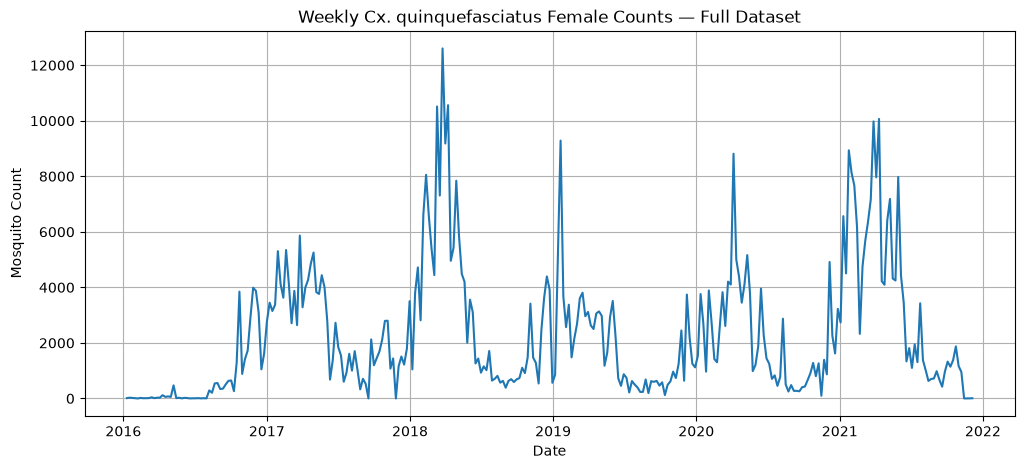

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(ts_full.index, ts_full["mosquito_count"])
plt.title("Weekly Cx. quinquefasciatus Female Counts — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.show()

In [5]:
ts_series = ts_full["mosquito_count"]

train_size = int(len(ts_series) * 0.8)

train_series = ts_series.iloc[:train_size]
test_series = ts_series.iloc[train_size:]

print("Train size:", len(train_series))
print("Test size:", len(test_series))
print("Train period:", train_series.index.min(), "to", train_series.index.max())
print("Test period:", test_series.index.min(), "to", test_series.index.max())


def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    nrmse = rmse / np.mean(y_true) if np.mean(y_true) != 0 else np.nan

    nonzero_mask = y_true != 0
    if np.sum(nonzero_mask) > 0:
        mape = np.mean(
            np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_mask = denominator != 0
    if np.sum(smape_mask) > 0:
        smape = np.mean(
            np.abs(y_true[smape_mask] - y_pred[smape_mask]) / denominator[smape_mask]
        ) * 100
    else:
        smape = np.nan

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "nRMSE": nrmse,
        "MAPE": mape,
        "SMAPE": smape
    }


model_results = []

def add_result(model_name, y_true, y_pred):
    metrics = compute_metrics(y_true, y_pred)
    model_results.append({
        "Series": "Full Dataset",
        "Model": model_name,
        **metrics
    })
    return metrics

Train size: 247
Test size: 62
Train period: 2016-01-10 00:00:00 to 2020-09-27 00:00:00
Test period: 2020-10-04 00:00:00 to 2021-12-05 00:00:00


In [6]:
def naive_forecast(train):
    return train.iloc[-1]

def seasonal_naive_forecast(train, season_length=52):
    if len(train) < season_length:
        return train.iloc[-1]
    return train.iloc[-season_length]

def rolling_mean_forecast(train, window=4):
    return train.iloc[-window:].mean()


def evaluate_expanding_baseline(ts, model_fn, initial_train_size, **kwargs):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        pred = model_fn(train, **kwargs)

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


INITIAL_TRAIN_SIZE = 52

baseline_specs = [
    ("Naive", naive_forecast, {}),
    ("Seasonal Naive", seasonal_naive_forecast, {"season_length": 52}),
    ("Rolling Mean", rolling_mean_forecast, {"window": 4})
]

for name, fn, kwargs in baseline_specs:
    y_true, y_pred = evaluate_expanding_baseline(
        ts_series,
        fn,
        initial_train_size=INITIAL_TRAIN_SIZE,
        **kwargs
    )
    
    metrics = add_result(name, y_true, y_pred)
    print(name, metrics)

baseline_df = pd.DataFrame(model_results)
baseline_df

Naive {'RMSE': np.float64(1628.0198291797108), 'MAE': 1110.0817120622569, 'R2': 0.5276533753855994, 'nRMSE': np.float64(0.6126873034642012), 'MAPE': np.float64(60.269076234907125), 'SMAPE': np.float64(49.02725334958663)}
Seasonal Naive {'RMSE': np.float64(2567.2366815290575), 'MAE': 1801.5642023346304, 'R2': -0.17455472059464827, 'nRMSE': np.float64(0.9661512050212225), 'MAPE': np.float64(475.62482848646255), 'SMAPE': np.float64(82.80015102252814)}
Rolling Mean {'RMSE': np.float64(1601.1727301786352), 'MAE': 1098.5933852140079, 'R2': 0.5431035269132073, 'nRMSE': np.float64(0.6025836939147442), 'MAPE': np.float64(146.54620420018492), 'SMAPE': np.float64(48.77813610987968)}


,Series,Model,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Full Dataset,Naive,1628.019829,1110.081712,0.527653,0.612687,60.269076,49.027253
1,Full Dataset,Seasonal Naive,2567.236682,1801.564202,-0.174555,0.966151,475.624828,82.800151
2,Full Dataset,Rolling Mean,1601.172730,1098.593385,0.543104,0.602584,146.546204,48.778136


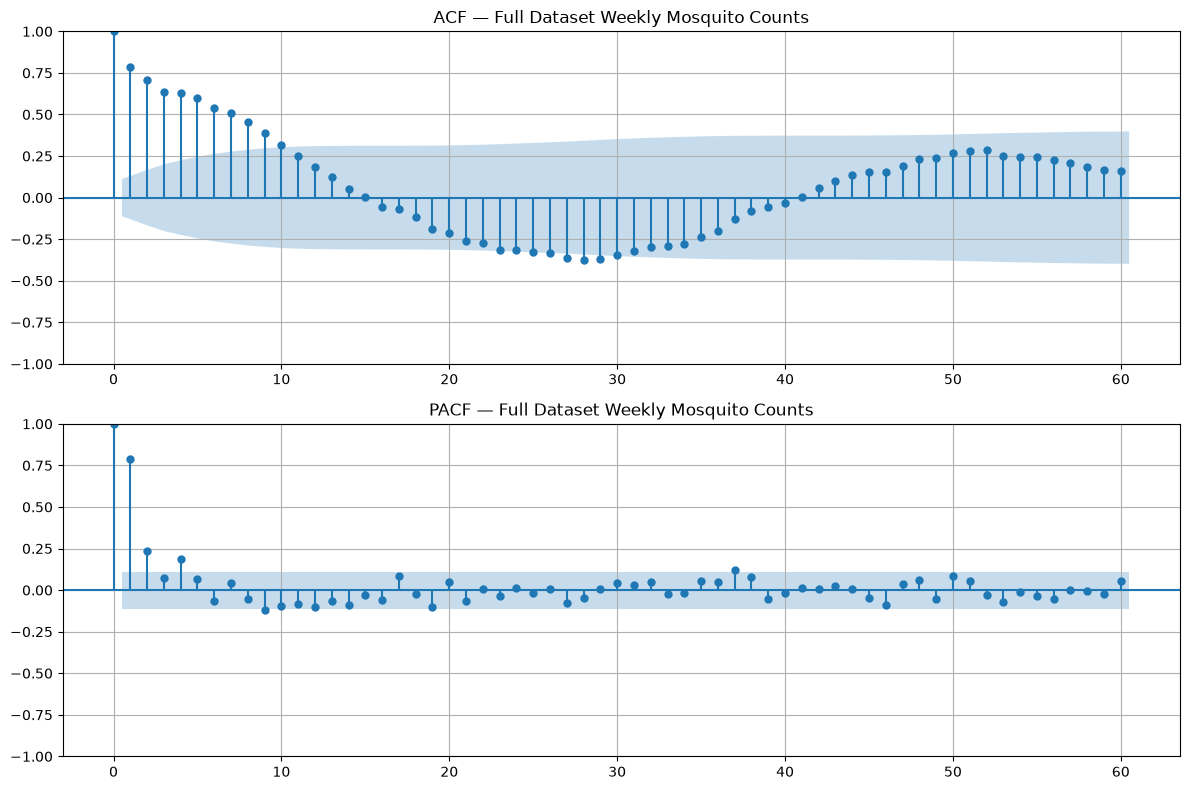

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(ts_series, lags=60, ax=axes[0])
axes[0].set_title("ACF — Full Dataset Weekly Mosquito Counts")

plot_pacf(ts_series, lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF — Full Dataset Weekly Mosquito Counts")

plt.tight_layout()
plt.show()

In [8]:
def stationarity_tests(ts):
    """
    Runs ADF and KPSS tests.
    ADF null hypothesis: series is non-stationary.
    KPSS null hypothesis: series is stationary.
    """
    ts_clean = ts.dropna()

    adf_result = adfuller(ts_clean, autolag="AIC")
    kpss_result = kpss(ts_clean, regression="c", nlags="auto")

    return pd.DataFrame({
        "Test": ["ADF", "KPSS"],
        "Statistic": [adf_result[0], kpss_result[0]],
        "p-value": [adf_result[1], kpss_result[1]]
    })

stationarity_tests(ts_series)

C:\Users\lamby\AppData\Local\Temp\ipykernel_2864\2365130481.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(ts_clean, regression="c", nlags="auto")


,Test,Statistic,p-value
0,ADF,-4.159626,0.000771
1,KPSS,0.174873,0.100000


In [9]:
def residual_diagnostics(residuals, fitted_values=None, title="Residual Diagnostics"):
    residuals = pd.Series(residuals).dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(residuals)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals Over Time")

    if fitted_values is not None:
        fitted_values = np.array(fitted_values)
        min_len = min(len(fitted_values), len(residuals))
        axes[0, 1].scatter(fitted_values[-min_len:], residuals[-min_len:])
        axes[0, 1].axhline(0, linestyle="--")
        axes[0, 1].set_title("Residuals vs Fitted")
    else:
        axes[0, 1].hist(residuals, bins=25)
        axes[0, 1].set_title("Residual Distribution")

    plot_acf(residuals, ax=axes[1, 0])
    axes[1, 0].set_title("ACF of Residuals")

    qqplot(residuals, line="s", ax=axes[1, 1])
    axes[1, 1].set_title("Q-Q Plot")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    print("Ljung-Box Test:")
    display(acorr_ljungbox(residuals, lags=[10, 20], return_df=True))

## ARIMA

In [10]:
def tune_arima(train, p_values, d_values, q_values):
    results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)

                try:
                    model = ARIMA(train, order=order)
                    fitted = model.fit()

                    results.append({
                        "order": order,
                        "AIC": fitted.aic,
                        "BIC": fitted.bic
                    })

                except Exception:
                    continue

    results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    return results_df


arima_tuning_results = tune_arima(
    train_series,
    p_values=range(0, 5),
    d_values=range(0, 2),
    q_values=range(0, 5)
)

arima_tuning_results.head(10)

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,AIC,BIC
0,"(4, 1, 4)",4225.882325,4257.430309
1,"(1, 1, 4)",4228.146214,4249.178204
2,"(3, 1, 2)",4228.267138,4249.299127
3,"(2, 1, 3)",4229.113070,4250.145060
4,"(4, 1, 0)",4229.367529,4246.894187
5,"(0, 1, 4)",4229.436277,4246.962935
6,"(2, 1, 4)",4229.643549,4254.180869
7,"(3, 1, 3)",4230.082729,4254.620049
8,"(4, 1, 1)",4230.706956,4251.738946
9,"(3, 1, 1)",4230.831196,4248.357854


Best ARIMA order: (4, 1, 4)


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'RMSE': np.float64(3957.966145490842), 'MAE': 2843.3680460173096, 'R2': -0.9817214731316024, 'nRMSE': np.float64(1.2826828339968126), 'MAPE': np.float64(319.5600589165911), 'SMAPE': np.float64(147.84993505552754)}


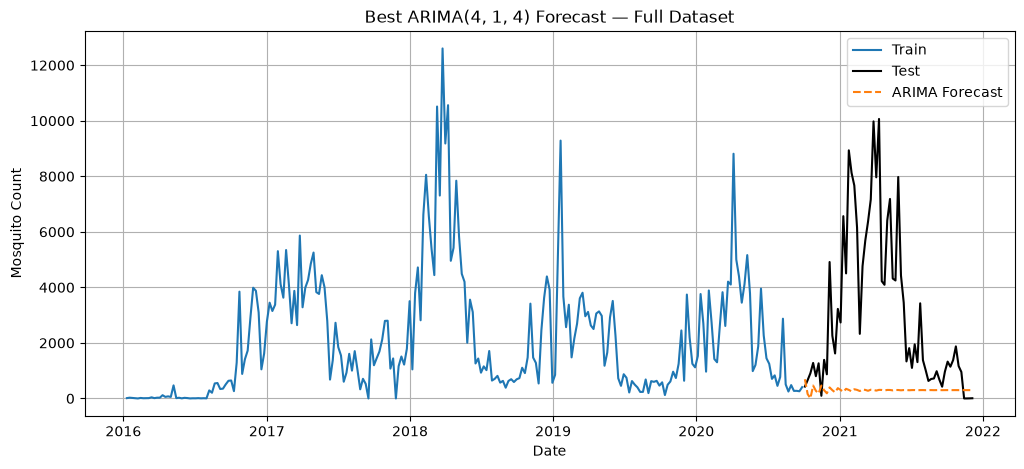

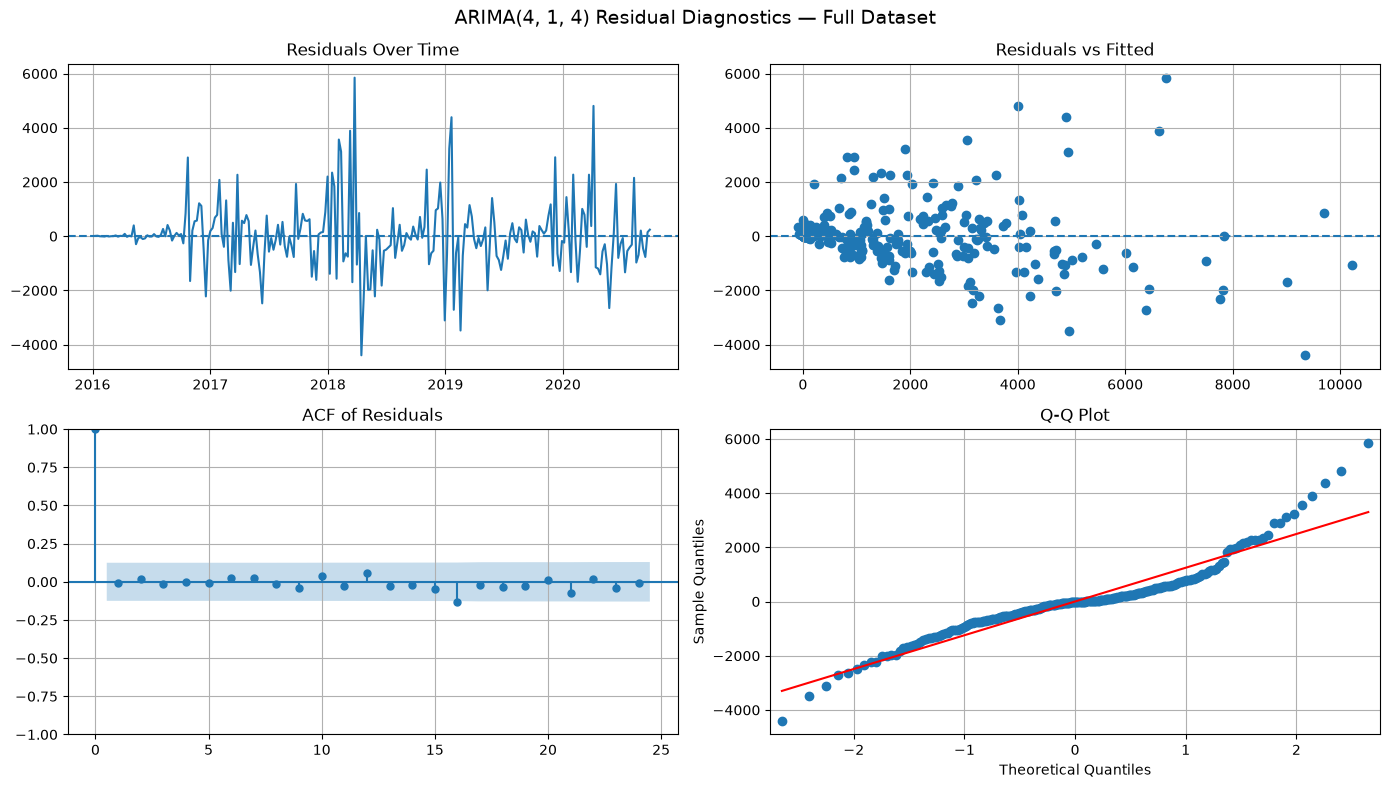

Ljung-Box Test:


,lb_stat,lb_pvalue
10,1.265165,0.999500
20,8.330588,0.989445


In [11]:
best_arima_order = arima_tuning_results.iloc[0]["order"]
print("Best ARIMA order:", best_arima_order)

best_arima = ARIMA(train_series, order=best_arima_order).fit()

arima_forecast = best_arima.forecast(steps=len(test_series))
arima_forecast.index = test_series.index
arima_forecast = np.maximum(arima_forecast, 0)

metrics = add_result(f"ARIMA{best_arima_order}", test_series, arima_forecast)
print(metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast", linestyle="--")
plt.title(f"Best ARIMA{best_arima_order} Forecast — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

residual_diagnostics(
    best_arima.resid,
    fitted_values=best_arima.fittedvalues,
    title=f"ARIMA{best_arima_order} Residual Diagnostics — Full Dataset"
)

In [12]:
log_train = np.log1p(train_series)
log_test = np.log1p(test_series)

log_arima_tuning_results = tune_arima(
    log_train,
    p_values=range(0, 5),
    d_values=range(0, 2),
    q_values=range(0, 5)
)

log_arima_tuning_results.head(10)

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages

,order,AIC,BIC
0,"(0, 1, 1)",718.588851,725.599514
1,"(1, 1, 1)",720.551462,731.067457
2,"(0, 1, 2)",720.551854,731.067848
3,"(1, 1, 2)",720.578926,734.600253
4,"(1, 1, 3)",722.360734,739.887392
5,"(2, 1, 2)",722.395513,739.922171
6,"(2, 1, 1)",722.548608,736.569934
7,"(0, 1, 3)",722.549970,736.571296
8,"(3, 1, 3)",723.378531,747.915851
9,"(3, 1, 0)",723.654802,737.676128


Best log-ARIMA order: (0, 1, 1)
{'RMSE': np.float64(3928.486797973315), 'MAE': 2795.4600011535044, 'R2': -0.9523112683756234, 'nRMSE': np.float64(1.2731292775417538), 'MAPE': np.float64(346.596816002793), 'SMAPE': np.float64(138.59936401701816)}


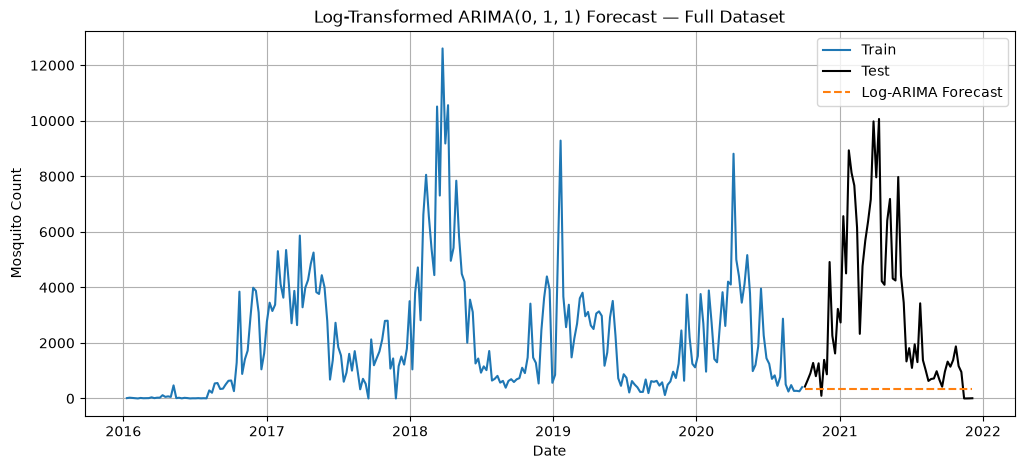

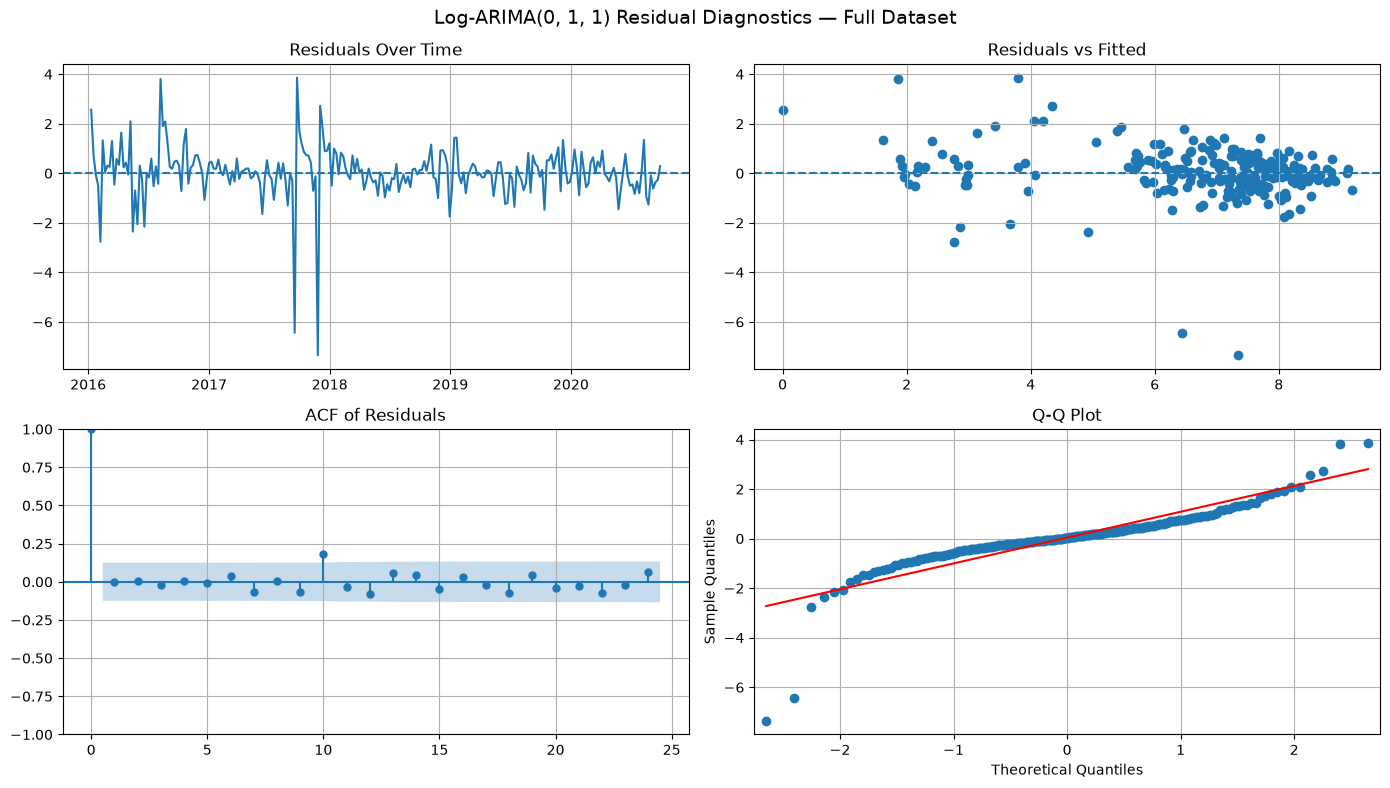

Ljung-Box Test:


,lb_stat,lb_pvalue
10,11.535765,0.317326
20,18.099229,0.580872


In [13]:
best_log_arima_order = log_arima_tuning_results.iloc[0]["order"]
print("Best log-ARIMA order:", best_log_arima_order)

best_log_arima = ARIMA(log_train, order=best_log_arima_order).fit()

log_forecast = best_log_arima.forecast(steps=len(test_series))
log_forecast.index = test_series.index

log_arima_forecast_original_scale = np.expm1(log_forecast)
log_arima_forecast_original_scale = np.maximum(log_arima_forecast_original_scale, 0)

metrics = add_result(
    f"Log-ARIMA{best_log_arima_order}",
    test_series,
    log_arima_forecast_original_scale
)

print(metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    log_arima_forecast_original_scale.index,
    log_arima_forecast_original_scale,
    label="Log-ARIMA Forecast",
    linestyle="--"
)
plt.title(f"Log-Transformed ARIMA{best_log_arima_order} Forecast — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

residual_diagnostics(
    best_log_arima.resid,
    fitted_values=best_log_arima.fittedvalues,
    title=f"Log-ARIMA{best_log_arima_order} Residual Diagnostics — Full Dataset"
)

In [14]:
def rolling_arima_forecast(ts, order, initial_train_size):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        try:
            model = ARIMA(train, order=order)
            fitted = model.fit()
            pred = fitted.forecast(steps=1).iloc[0]
            pred = max(pred, 0)
        except Exception:
            pred = train.iloc[-1]

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


y_true_roll_arima, y_pred_roll_arima = rolling_arima_forecast(
    ts_series,
    order=best_arima_order,
    initial_train_size=INITIAL_TRAIN_SIZE
)

metrics_roll_arima = compute_metrics(y_true_roll_arima, y_pred_roll_arima)
print(metrics_roll_arima)

add_result(
    f"Rolling ARIMA{best_arima_order}",
    y_true_roll_arima,
    y_pred_roll_arima
)

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages

{'RMSE': np.float64(1618.6431676512223), 'MAE': 1132.2491054458571, 'R2': 0.5330787144649883, 'nRMSE': np.float64(0.6091585003351381), 'MAPE': np.float64(169.7023727783699), 'SMAPE': np.float64(54.727681898525816)}


{'RMSE': np.float64(1618.6431676512223),
 'MAE': 1132.2491054458571,
 'R2': 0.5330787144649883,
 'nRMSE': np.float64(0.6091585003351381),
 'MAPE': np.float64(169.7023727783699),
 'SMAPE': np.float64(54.727681898525816)}

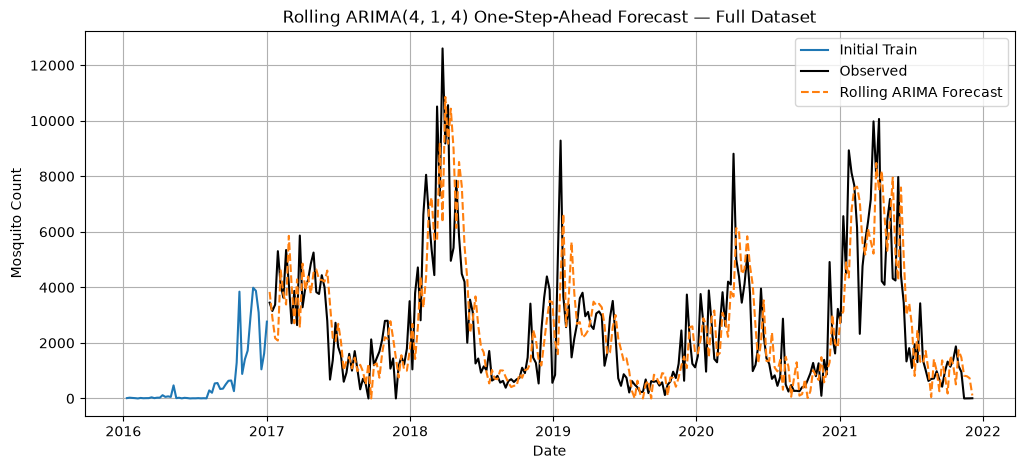

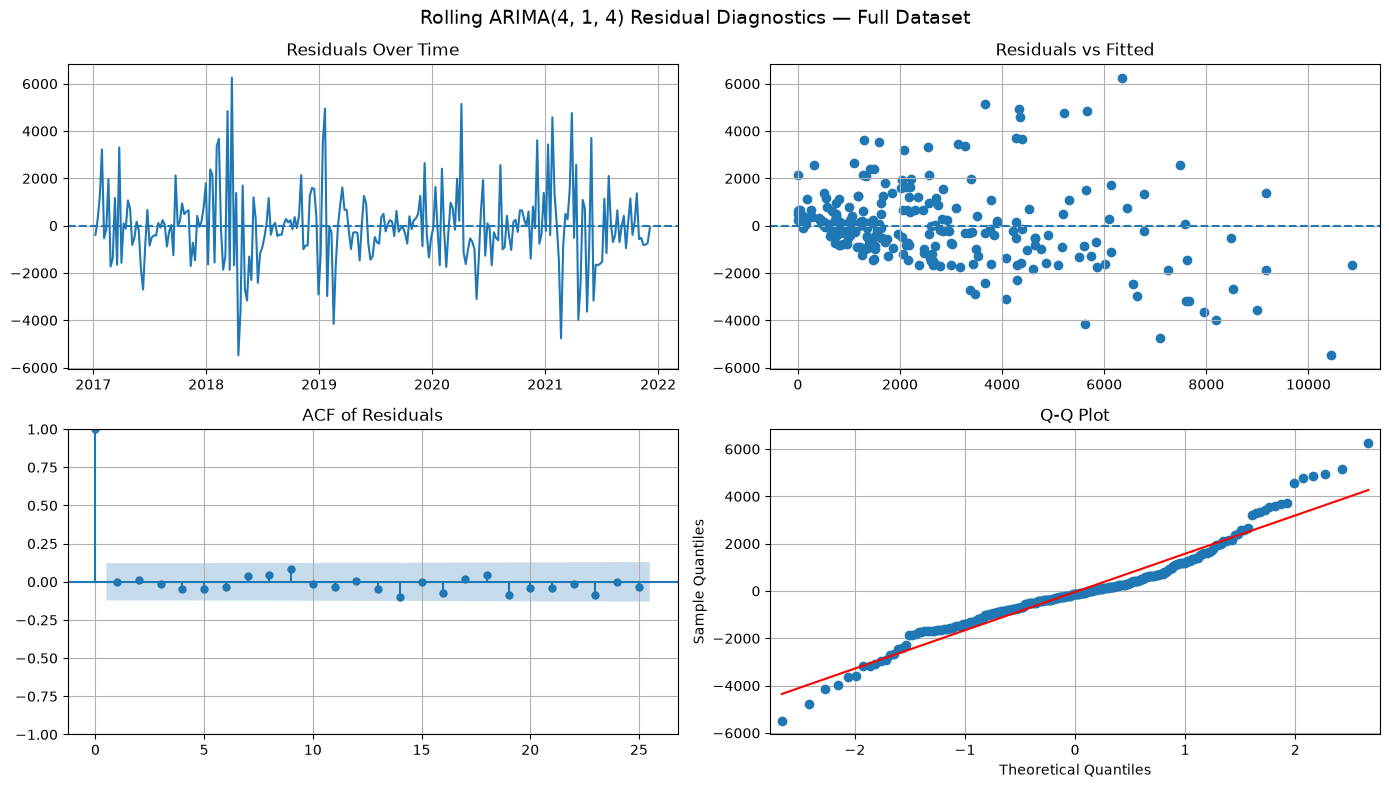

Ljung-Box Test:


,lb_stat,lb_pvalue
10,4.345638,0.930411
20,12.866751,0.883028


,lb_stat,lb_pvalue
10,4.345638,0.930411
20,12.866751,0.883028
30,20.978496,0.888559


In [15]:
rolling_start_index = ts_series.index[INITIAL_TRAIN_SIZE:]

rolling_arima_true = pd.Series(
    y_true_roll_arima,
    index=rolling_start_index,
    name="True"
)

rolling_arima_pred = pd.Series(
    y_pred_roll_arima,
    index=rolling_start_index,
    name="Rolling ARIMA Forecast"
)

rolling_arima_residuals = rolling_arima_true - rolling_arima_pred

plt.figure(figsize=(12, 5))

plt.plot(
    ts_series.index[:INITIAL_TRAIN_SIZE],
    ts_series.iloc[:INITIAL_TRAIN_SIZE],
    label="Initial Train"
)

plt.plot(
    rolling_arima_true.index,
    rolling_arima_true,
    label="Observed",
    color="black"
)

plt.plot( 
    rolling_arima_pred.index,
    rolling_arima_pred,
    label="Rolling ARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling ARIMA{best_arima_order} One-Step-Ahead Forecast — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

residual_diagnostics(
    rolling_arima_residuals,
    fitted_values=rolling_arima_pred,
    title=f"Rolling ARIMA{best_arima_order} Residual Diagnostics — Full Dataset"
)

display(
    acorr_ljungbox(
        rolling_arima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [16]:
def rolling_log_arima_forecast(ts, order, initial_train_size):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        log_train = np.log1p(train)

        try:
            model = ARIMA(log_train, order=order)
            fitted = model.fit()

            log_pred = fitted.forecast(steps=1).iloc[0]
            pred = np.expm1(log_pred)
            pred = max(pred, 0)

        except Exception:
            pred = train.iloc[-1]

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


y_true_roll_log_arima, y_pred_roll_log_arima = rolling_log_arima_forecast(
    ts_series,
    order=best_arima_order,
    initial_train_size=INITIAL_TRAIN_SIZE
)

metrics_roll_log_arima = compute_metrics(
    y_true_roll_log_arima,
    y_pred_roll_log_arima
)

print(metrics_roll_log_arima)

add_result(
    f"Rolling Log-ARIMA{best_arima_order}",
    y_true_roll_log_arima,
    y_pred_roll_log_arima
)

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\lamby\AppData\Local\Packages

{'RMSE': np.float64(1913.5678018164258), 'MAE': 1268.1416626108837, 'R2': 0.34742693340642516, 'nRMSE': np.float64(0.7201501329879724), 'MAPE': np.float64(63.9935685800192), 'SMAPE': np.float64(54.36754743831098)}


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'RMSE': np.float64(1913.5678018164258),
 'MAE': 1268.1416626108837,
 'R2': 0.34742693340642516,
 'nRMSE': np.float64(0.7201501329879724),
 'MAPE': np.float64(63.9935685800192),
 'SMAPE': np.float64(54.36754743831098)}

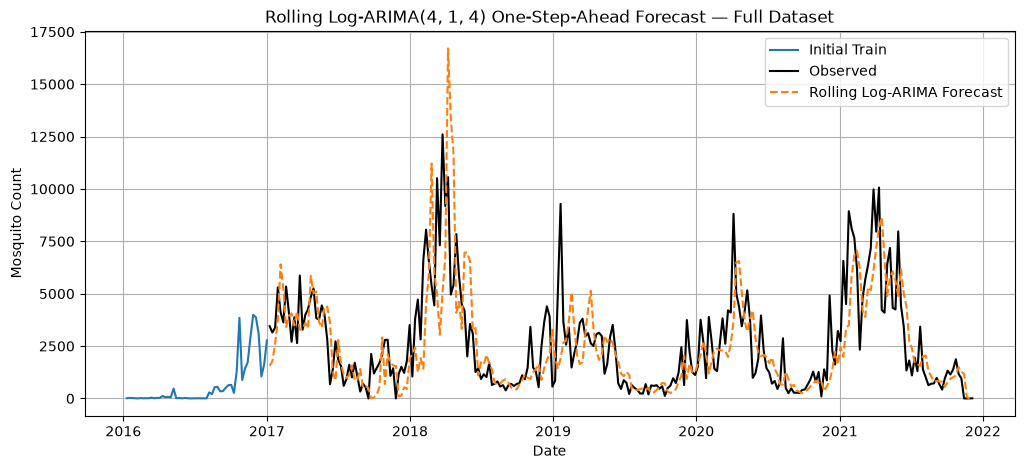

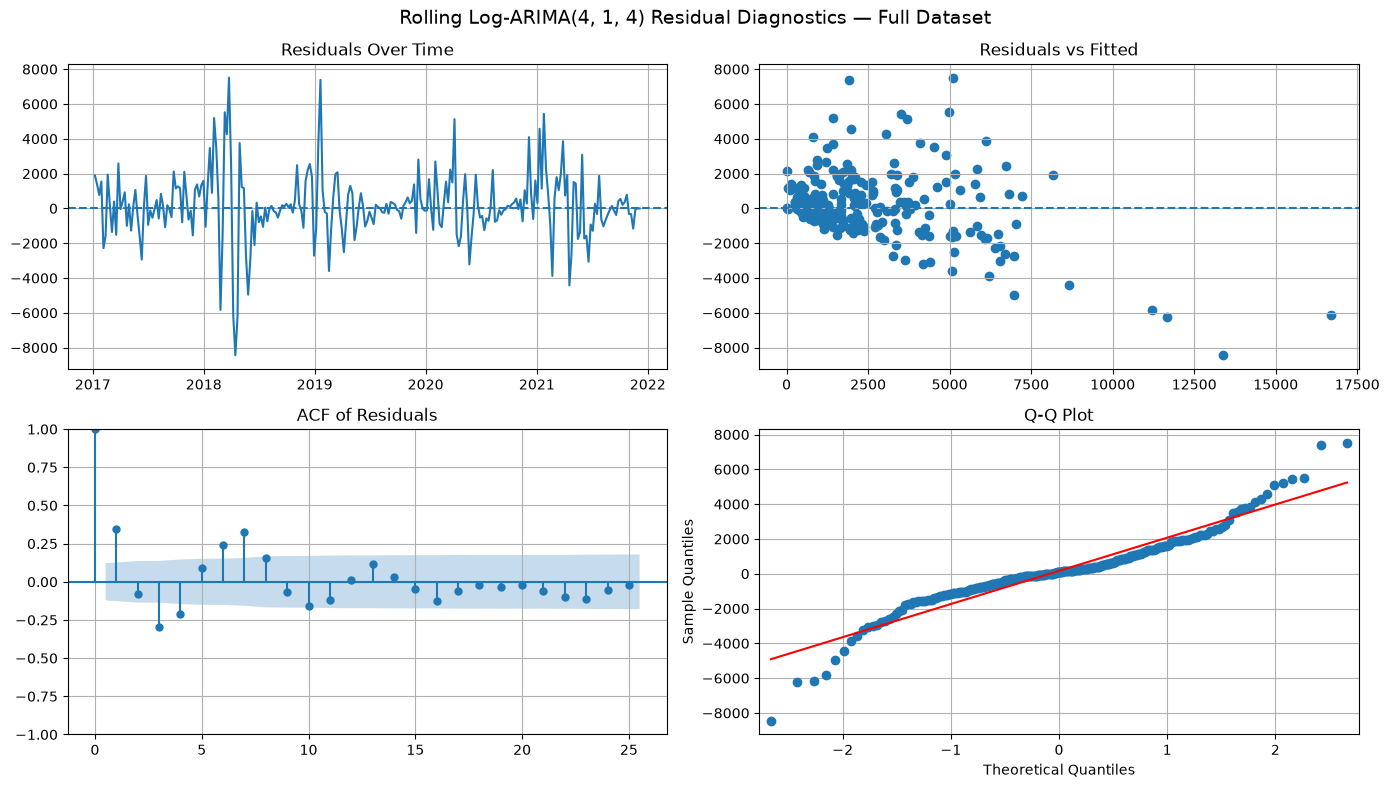

Ljung-Box Test:


,lb_stat,lb_pvalue
10,128.340747,1.018067e-22
20,143.026857,1.346752e-20


,lb_stat,lb_pvalue
10,128.340747,1.018067e-22
20,143.026857,1.346752e-20
30,166.655206,6.927536e-21


In [17]:
rolling_log_arima_index = ts_series.index[INITIAL_TRAIN_SIZE:]

rolling_log_arima_true = pd.Series(
    y_true_roll_log_arima,
    index=rolling_log_arima_index,
    name="Observed"
)

rolling_log_arima_pred = pd.Series(
    y_pred_roll_log_arima,
    index=rolling_log_arima_index,
    name="Rolling Log-ARIMA Forecast"
)

rolling_log_arima_residuals = rolling_log_arima_true - rolling_log_arima_pred

plt.figure(figsize=(12, 5))

plt.plot(
    ts_series.index[:INITIAL_TRAIN_SIZE],
    ts_series.iloc[:INITIAL_TRAIN_SIZE],
    label="Initial Train"
)

plt.plot(
    rolling_log_arima_true.index,
    rolling_log_arima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_log_arima_pred.index,
    rolling_log_arima_pred,
    label="Rolling Log-ARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling Log-ARIMA{best_arima_order} One-Step-Ahead Forecast — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

residual_diagnostics(
    rolling_log_arima_residuals,
    fitted_values=rolling_log_arima_pred,
    title=f"Rolling Log-ARIMA{best_arima_order} Residual Diagnostics — Full Dataset"
)

display(
    acorr_ljungbox(
        rolling_log_arima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [18]:
arima_results = []

def add_arima_result(model_name, order, y_true, y_pred, fitted_model=None):
    metrics = compute_metrics(y_true, y_pred)

    if fitted_model is not None:
        aic = fitted_model.aic
        bic = fitted_model.bic
    else:
        aic = np.nan
        bic = np.nan

    arima_results.append({
        "Model": model_name,
        "Order": str(order),
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R2": metrics["R2"],
        "nRMSE": metrics["nRMSE"],
        "MAPE": metrics["MAPE"],
        "SMAPE": metrics["SMAPE"],
        "AIC": aic,
        "BIC": bic
    })


add_arima_result(
    model_name="ARIMA One-Shot",
    order=best_arima_order,
    y_true=test_series,
    y_pred=arima_forecast,
    fitted_model=best_arima
)

add_arima_result(
    model_name="Log-ARIMA One-Shot",
    order=best_log_arima_order,
    y_true=test_series,
    y_pred=log_arima_forecast_original_scale,
    fitted_model=best_log_arima
)

add_arima_result(
    model_name="Rolling ARIMA",
    order=best_arima_order,
    y_true=y_true_roll_arima,
    y_pred=y_pred_roll_arima,
    fitted_model=None
)

add_arima_result(
    model_name="Rolling Log-ARIMA",
    order=best_arima_order,
    y_true=y_true_roll_log_arima,
    y_pred=y_pred_roll_log_arima,
    fitted_model=None
)

arima_results_df = pd.DataFrame(arima_results)
arima_results_df = arima_results_df.sort_values("RMSE").reset_index(drop=True)

arima_results_df

,Model,Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Rolling ARIMA,"(4, 1, 4)",1618.643168,1132.249105,0.533079,0.609159,169.702373,54.727682,NaN,NaN
1,Rolling Log-ARIMA,"(4, 1, 4)",1913.567802,1268.141663,0.347427,0.720150,63.993569,54.367547,NaN,NaN
2,Log-ARIMA One-Shot,"(0, 1, 1)",3928.486798,2795.460001,-0.952311,1.273129,346.596816,138.599364,718.588851,725.599514
3,ARIMA One-Shot,"(4, 1, 4)",3957.966145,2843.368046,-0.981721,1.282683,319.560059,147.849935,4225.882325,4257.430309


In [19]:
arima_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Model,Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Rolling ARIMA,"(4, 1, 4)",1618.64,1132.25,0.533,0.609,169.70,54.73,nan,nan
1,Rolling Log-ARIMA,"(4, 1, 4)",1913.57,1268.14,0.347,0.720,63.99,54.37,nan,nan
2,Log-ARIMA One-Shot,"(0, 1, 1)",3928.49,2795.46,-0.952,1.273,346.60,138.60,718.59,725.60
3,ARIMA One-Shot,"(4, 1, 4)",3957.97,2843.37,-0.982,1.283,319.56,147.85,4225.88,4257.43


## SARIMA

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

In [21]:
def tune_sarima_small(train, seasonal_period=52):
    """
    Small SARIMA tuning grid designed to run in reasonable time.
    """
    
    candidate_orders = [
        (1, 0, 0),
        (1, 0, 1),
        (2, 0, 1),
        (3, 0, 1),
        (3, 0, 2),
        (3, 0, 4),
    ]
    
    candidate_seasonal_orders = [
        (0, 0, 0, seasonal_period),
        (1, 0, 0, seasonal_period),
        (0, 0, 1, seasonal_period),
        (1, 0, 1, seasonal_period),
        (1, 1, 0, seasonal_period),
        (0, 1, 1, seasonal_period),
    ]
    
    results = []
    start_time = time.time()
    
    for order in candidate_orders:
        for seasonal_order in candidate_seasonal_orders:
            try:
                model = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                
                fitted = model.fit(disp=False, maxiter=75)
                
                results.append({
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic
                })
                
                print(f"Finished SARIMA{order}{seasonal_order} | AIC: {fitted.aic:.2f}")
            
            except Exception as e:
                print(f"Failed SARIMA{order}{seasonal_order}: {e}")
                continue
    
    elapsed = time.time() - start_time
    print(f"\nTuning completed in {elapsed/60:.2f} minutes")
    
    results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    return results_df


sarima_tuning_results = tune_sarima_small(
    train_series,
    seasonal_period=52
)

sarima_tuning_results.head(10)

Finished SARIMA(1, 0, 0)(0, 0, 0, 52) | AIC: 4262.65
Finished SARIMA(1, 0, 0)(1, 0, 0, 52) | AIC: 3393.14
Finished SARIMA(1, 0, 0)(0, 0, 1, 52) | AIC: 3396.76
Finished SARIMA(1, 0, 0)(1, 0, 1, 52) | AIC: 3394.93
Finished SARIMA(1, 0, 0)(1, 1, 0, 52) | AIC: 2527.45


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(1, 0, 0)(0, 1, 1, 52) | AIC: 4836.68
Finished SARIMA(1, 0, 1)(0, 0, 0, 52) | AIC: 4218.79
Finished SARIMA(1, 0, 1)(1, 0, 0, 52) | AIC: 3374.24
Finished SARIMA(1, 0, 1)(0, 0, 1, 52) | AIC: 3358.59
Finished SARIMA(1, 0, 1)(1, 0, 1, 52) | AIC: 3355.45
Finished SARIMA(1, 0, 1)(1, 1, 0, 52) | AIC: 2523.37


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(1, 0, 1)(0, 1, 1, 52) | AIC: 4131.96
Finished SARIMA(2, 0, 1)(0, 0, 0, 52) | AIC: 4218.42
Finished SARIMA(2, 0, 1)(1, 0, 0, 52) | AIC: 3357.09
Finished SARIMA(2, 0, 1)(0, 0, 1, 52) | AIC: 3358.29
Finished SARIMA(2, 0, 1)(1, 0, 1, 52) | AIC: 3352.79
Finished SARIMA(2, 0, 1)(1, 1, 0, 52) | AIC: 2503.40


...

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(3, 0, 2)(0, 1, 1, 52) | AIC: 3779.30
Finished SARIMA(3, 0, 4)(0, 0, 0, 52) | AIC: 4162.31
Finished SARIMA(3, 0, 4)(1, 0, 0, 52) | AIC: 3332.37
Finished SARIMA(3, 0, 4)(0, 0, 1, 52) | AIC: 3298.93
Finished SARIMA(3, 0, 4)(1, 0, 1, 52) | AIC: 3298.50
Finished SARIMA(3, 0, 4)(1, 1, 0, 52) | AIC: 2477.27


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(3, 0, 4)(0, 1, 1, 52) | AIC: 5214.97

Tuning completed in 9.05 minutes


,order,seasonal_order,AIC,BIC
0,"(3, 0, 2)","(1, 1, 0, 52)",2475.749162,2496.340659
1,"(3, 0, 4)","(1, 1, 0, 52)",2477.274866,2503.749647
2,"(3, 0, 1)","(1, 1, 0, 52)",2485.649004,2503.298859
3,"(2, 0, 1)","(1, 1, 0, 52)",2503.400849,2518.144649
4,"(1, 0, 1)","(1, 1, 0, 52)",2523.371396,2535.194704
5,"(1, 0, 0)","(1, 1, 0, 52)",2527.447438,2536.314919
6,"(3, 0, 4)","(1, 0, 1, 52)",3298.496503,3330.966744
7,"(3, 0, 4)","(0, 0, 1, 52)",3298.930318,3328.153534
8,"(3, 0, 4)","(1, 0, 0, 52)",3332.372596,3361.690054
9,"(3, 0, 2)","(1, 0, 0, 52)",3333.545088,3356.347555


In [22]:
best_sarima_order = sarima_tuning_results.iloc[0]["order"]
best_sarima_seasonal_order = sarima_tuning_results.iloc[0]["seasonal_order"]

print("Best SARIMA order:", best_sarima_order)
print("Best SARIMA seasonal order:", best_sarima_seasonal_order)

best_sarima = SARIMAX(
    train_series,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=100)

sarima_forecast = best_sarima.forecast(steps=len(test_series))
sarima_forecast.index = test_series.index
sarima_forecast = np.maximum(sarima_forecast, 0)

sarima_metrics = compute_metrics(test_series, sarima_forecast)
print(sarima_metrics)

add_result(
    f"SARIMA{best_sarima_order}{best_sarima_seasonal_order}",
    test_series,
    sarima_forecast
)

Best SARIMA order: (3, 0, 2)
Best SARIMA seasonal order: (1, 1, 0, 52)
{'RMSE': np.float64(2440.321915218736), 'MAE': 1734.7405218563583, 'R2': 0.24665709026487748, 'nRMSE': np.float64(0.7908503799718872), 'MAPE': np.float64(1421.2984913339988), 'SMAPE': np.float64(79.93103697919389)}


{'RMSE': np.float64(2440.321915218736),
 'MAE': 1734.7405218563583,
 'R2': 0.24665709026487748,
 'nRMSE': np.float64(0.7908503799718872),
 'MAPE': np.float64(1421.2984913339988),
 'SMAPE': np.float64(79.93103697919389)}

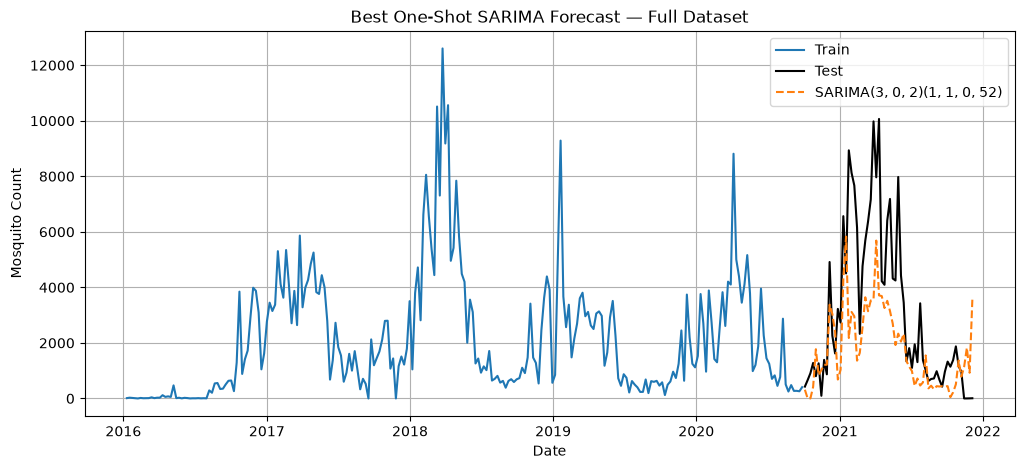

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label=f"SARIMA{best_sarima_order}{best_sarima_seasonal_order}",
    linestyle="--"
)

plt.title("Best One-Shot SARIMA Forecast — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

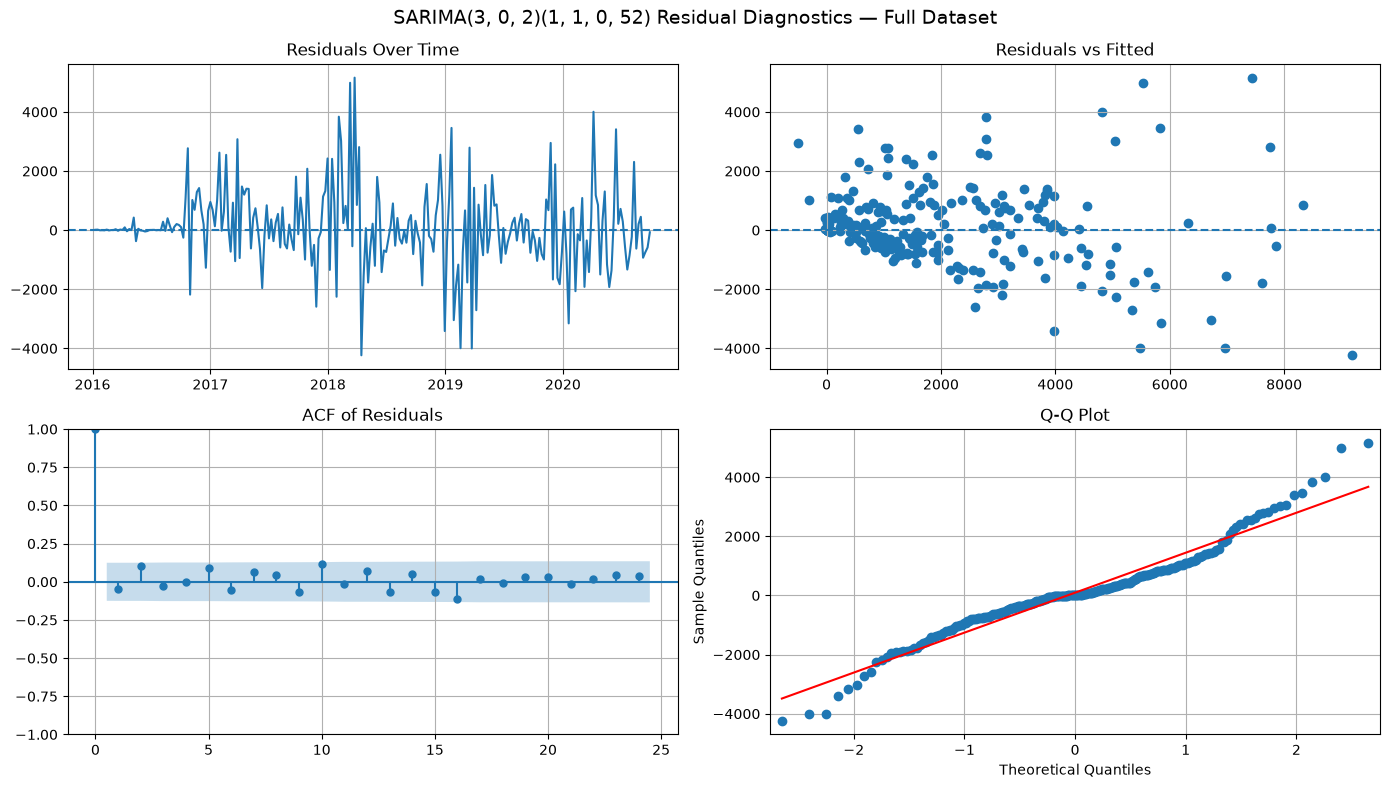

Ljung-Box Test:


,lb_stat,lb_pvalue
10,12.381434,0.260339
20,21.005344,0.396818


,lb_stat,lb_pvalue
10,12.381434,0.260339
20,21.005344,0.396818
30,26.376452,0.655786


In [24]:
residual_diagnostics(
    best_sarima.resid,
    fitted_values=best_sarima.fittedvalues,
    title=f"SARIMA{best_sarima_order}{best_sarima_seasonal_order} Residual Diagnostics — Full Dataset"
)

display(
    acorr_ljungbox(
        pd.Series(best_sarima.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [25]:
def fast_rolling_sarima_forecast(
    ts,
    order,
    seasonal_order,
    initial_train_size,
    refit_every=8,
    maxiter=25
):
    
    
    y_true, y_pred = [], []
    pred_index = []
    
    start_time = time.time()
    
    i = initial_train_size
    
    while i < len(ts):
        train = ts.iloc[:i]
        
        steps = min(refit_every, len(ts) - i)
        test_block = ts.iloc[i:i + steps]
        
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
                simple_differencing=True
            )
            
            fitted = model.fit(
                disp=False,
                maxiter=maxiter,
                method="powell"
            )
            
            forecast = fitted.forecast(steps=steps)
            forecast = np.maximum(forecast.values, 0)
        
        except Exception:
            forecast = np.repeat(train.iloc[-1], steps)
        
        y_true.extend(test_block.values)
        y_pred.extend(forecast)
        pred_index.extend(test_block.index)
        
        print(f"Completed forecasts through index {i + steps} / {len(ts)}")
        
        i += steps
    
    elapsed = time.time() - start_time
    print(f"\nFast rolling SARIMA completed in {elapsed/60:.2f} minutes")
    
    return (
        np.array(y_true),
        np.array(y_pred),
        pd.Index(pred_index)
    )

In [26]:
fast_sarima_order = best_sarima_order
fast_sarima_seasonal_order = best_sarima_seasonal_order

y_true_roll_sarima, y_pred_roll_sarima, roll_sarima_index = fast_rolling_sarima_forecast(
    ts_series,
    order=fast_sarima_order,
    seasonal_order=fast_sarima_seasonal_order,
    initial_train_size=INITIAL_TRAIN_SIZE,
    refit_every=8,
    maxiter=25
)

rolling_sarima_metrics = compute_metrics(
    y_true_roll_sarima,
    y_pred_roll_sarima
)

print(rolling_sarima_metrics)

add_result(
    f"Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order}",
    y_true_roll_sarima,
    y_pred_roll_sarima
)

Completed forecasts through index 60 / 309
Completed forecasts through index 68 / 309
Completed forecasts through index 76 / 309


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Completed forecasts through index 84 / 309
Completed forecasts through index 92 / 309
Completed forecasts through index 100 / 309
Completed forecasts through index 108 / 309
Completed forecasts through index 116 / 309
Completed forecasts through index 124 / 309
Completed forecasts through index 132 / 309
Completed forecasts through index 140 / 309
Completed forecasts through index 148 / 309
Completed forecasts through index 156 / 309
Completed forecasts through index 164 / 309
Completed forecasts through index 172 / 309
Completed forecasts through index 180 / 309
Completed forecasts through index 188 / 309
Completed forecasts through index 196 / 309
Completed forecasts through index 204 / 309
Completed forecasts through index 212 / 309
Completed forecasts through index 220 / 309
Completed forecasts through index 228 / 309
Completed forecasts through index 236 / 309
Completed forecasts through index 244 / 309
Completed forecasts through index 252 / 309
Completed forecasts through index 

{'RMSE': np.float64(89631.24383081018),
 'MAE': 13277.442357874617,
 'R2': -1430.7272212411485,
 'nRMSE': np.float64(33.73172986259706),
 'MAPE': np.float64(599.057030136064),
 'SMAPE': np.float64(129.95507555819776)}

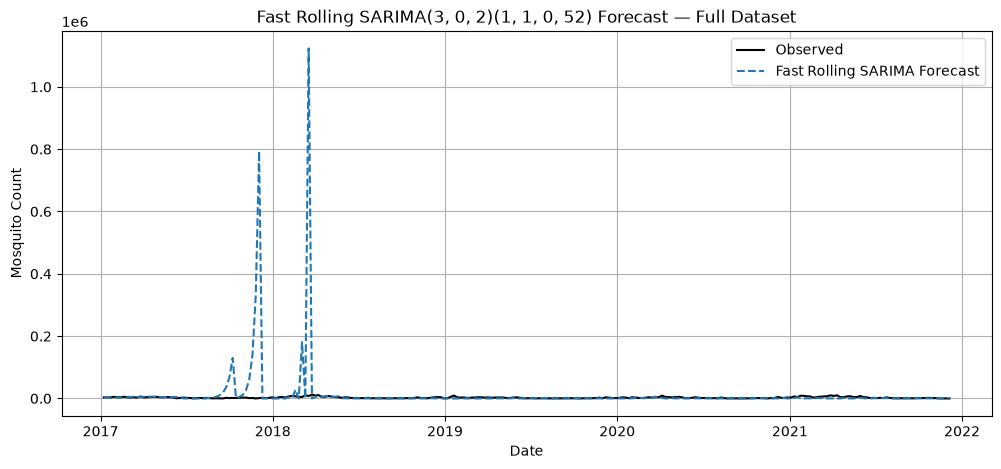

In [27]:
rolling_sarima_true = pd.Series(
    y_true_roll_sarima,
    index=roll_sarima_index,
    name="Observed"
)

rolling_sarima_pred = pd.Series(
    y_pred_roll_sarima,
    index=roll_sarima_index,
    name="Fast Rolling SARIMA Forecast"
)

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_sarima_true.index,
    rolling_sarima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_sarima_pred.index,
    rolling_sarima_pred,
    label="Fast Rolling SARIMA Forecast",
    linestyle="--"
)

plt.title(f"Fast Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order} Forecast — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

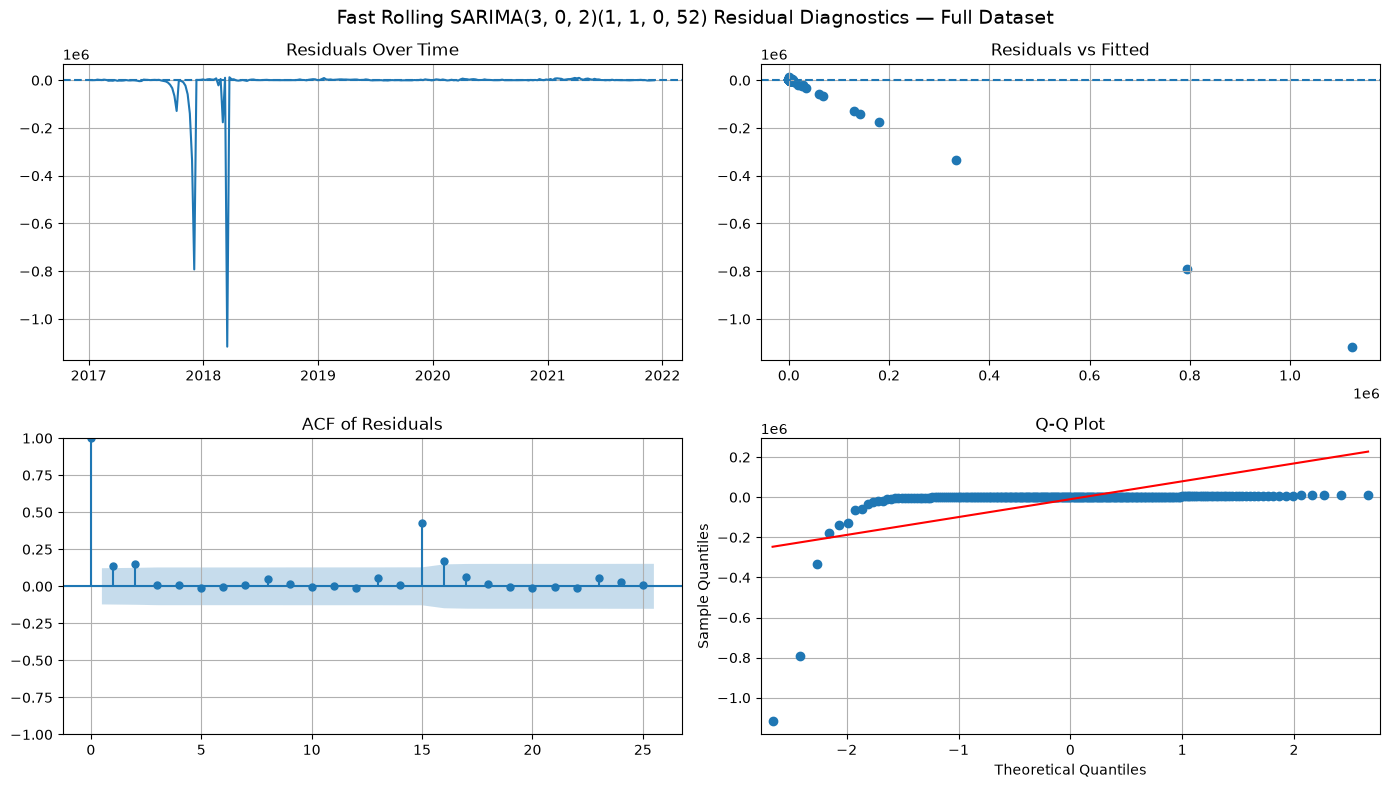

Ljung-Box Test:


,lb_stat,lb_pvalue
10,11.701935,3.055001e-01
20,72.508655,7.055903e-08


,lb_stat,lb_pvalue
10,11.701935,3.055001e-01
20,72.508655,7.055903e-08
30,73.932337,1.416640e-05


In [28]:
rolling_sarima_residuals = rolling_sarima_true - rolling_sarima_pred

residual_diagnostics(
    rolling_sarima_residuals,
    fitted_values=rolling_sarima_pred,
    title=f"Fast Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order} Residual Diagnostics — Full Dataset"
)

display(
    acorr_ljungbox(
        rolling_sarima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [29]:
log_train_series = np.log1p(train_series)

log_sarima_tuning_results = tune_sarima_small(
    log_train_series,
    seasonal_period=52
)

log_sarima_tuning_results.head(10)

Finished SARIMA(1, 0, 0)(0, 0, 0, 52) | AIC: 792.22
Finished SARIMA(1, 0, 0)(1, 0, 0, 52) | AIC: 623.37
Finished SARIMA(1, 0, 0)(0, 0, 1, 52) | AIC: 621.40
Finished SARIMA(1, 0, 0)(1, 0, 1, 52) | AIC: 609.46
Finished SARIMA(1, 0, 0)(1, 1, 0, 52) | AIC: 419.72


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(1, 0, 0)(0, 1, 1, 52) | AIC: 5263.17
Finished SARIMA(1, 0, 1)(0, 0, 0, 52) | AIC: 718.61
Finished SARIMA(1, 0, 1)(1, 0, 0, 52) | AIC: 554.44
Finished SARIMA(1, 0, 1)(0, 0, 1, 52) | AIC: 547.39
Finished SARIMA(1, 0, 1)(1, 0, 1, 52) | AIC: 549.69
Finished SARIMA(1, 0, 1)(1, 1, 0, 52) | AIC: 396.83


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(1, 0, 1)(0, 1, 1, 52) | AIC: 4126.85
Finished SARIMA(2, 0, 1)(0, 0, 0, 52) | AIC: 720.53
Finished SARIMA(2, 0, 1)(1, 0, 0, 52) | AIC: 554.53
Finished SARIMA(2, 0, 1)(0, 0, 1, 52) | AIC: 549.29
Finished SARIMA(2, 0, 1)(1, 0, 1, 52) | AIC: 551.29
Finished SARIMA(2, 0, 1)(1, 1, 0, 52) | AIC: 392.66


...

C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(3, 0, 4)(1, 1, 0, 52) | AIC: 388.37


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished SARIMA(3, 0, 4)(0, 1, 1, 52) | AIC: 1958.55

Tuning completed in 8.17 minutes


,order,seasonal_order,AIC,BIC
0,"(3, 0, 4)","(1, 1, 0, 52)",388.374979,414.849761
1,"(3, 0, 1)","(1, 1, 0, 52)",392.070276,409.720130
2,"(2, 0, 1)","(1, 1, 0, 52)",392.658523,407.402322
3,"(3, 0, 2)","(1, 1, 0, 52)",393.453086,414.044583
4,"(1, 0, 1)","(1, 1, 0, 52)",396.832064,408.655372
5,"(1, 0, 0)","(1, 1, 0, 52)",419.722029,428.589510
6,"(1, 0, 1)","(0, 0, 1, 52)",547.385431,560.436192
7,"(3, 0, 2)","(0, 0, 1, 52)",548.236338,571.038805
8,"(3, 0, 4)","(0, 0, 1, 52)",549.212345,578.435562
9,"(2, 0, 1)","(0, 0, 1, 52)",549.290339,565.603789


In [30]:
best_log_sarima_order = log_sarima_tuning_results.iloc[0]["order"]
best_log_sarima_seasonal_order = log_sarima_tuning_results.iloc[0]["seasonal_order"]

print("Best Log-SARIMA order:", best_log_sarima_order)
print("Best Log-SARIMA seasonal order:", best_log_sarima_seasonal_order)

best_log_sarima = SARIMAX(
    log_train_series,
    order=best_log_sarima_order,
    seasonal_order=best_log_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=100)

log_sarima_forecast = best_log_sarima.forecast(steps=len(test_series))
log_sarima_forecast.index = test_series.index

log_sarima_forecast_original = np.expm1(log_sarima_forecast)
log_sarima_forecast_original = np.maximum(log_sarima_forecast_original, 0)

log_sarima_metrics = compute_metrics(
    test_series,
    log_sarima_forecast_original
)

print(log_sarima_metrics)

add_result(
    f"Log-SARIMA{best_log_sarima_order}{best_log_sarima_seasonal_order}",
    test_series,
    log_sarima_forecast_original
)

Best Log-SARIMA order: (3, 0, 4)
Best Log-SARIMA seasonal order: (1, 1, 0, 52)


C:\Users\lamby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'RMSE': np.float64(2380.580771347957), 'MAE': 1629.1381713505627, 'R2': 0.2830905457924776, 'nRMSE': np.float64(0.7714896939757013), 'MAPE': np.float64(1622.9322131218946), 'SMAPE': np.float64(67.71589766985663)}


{'RMSE': np.float64(2380.580771347957),
 'MAE': 1629.1381713505627,
 'R2': 0.2830905457924776,
 'nRMSE': np.float64(0.7714896939757013),
 'MAPE': np.float64(1622.9322131218946),
 'SMAPE': np.float64(67.71589766985663)}

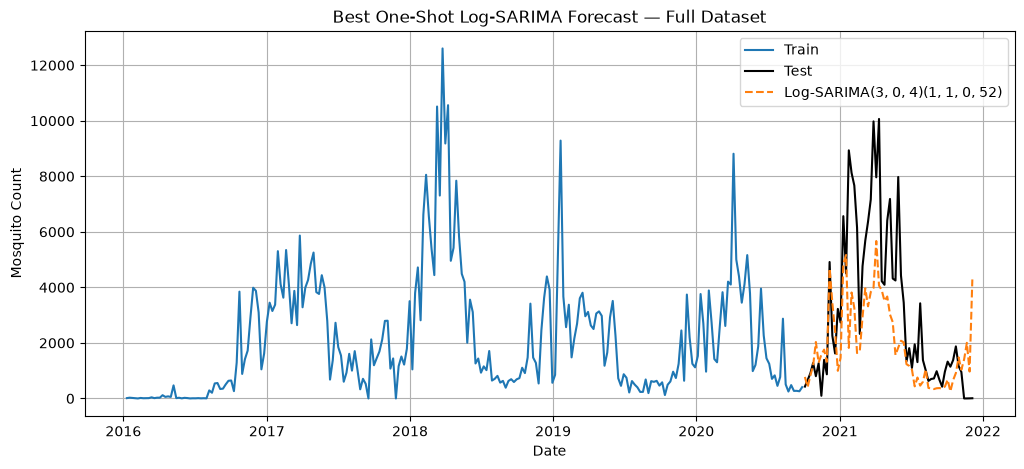

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    log_sarima_forecast_original.index,
    log_sarima_forecast_original,
    label=f"Log-SARIMA{best_log_sarima_order}{best_log_sarima_seasonal_order}",
    linestyle="--"
)

plt.title("Best One-Shot Log-SARIMA Forecast — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

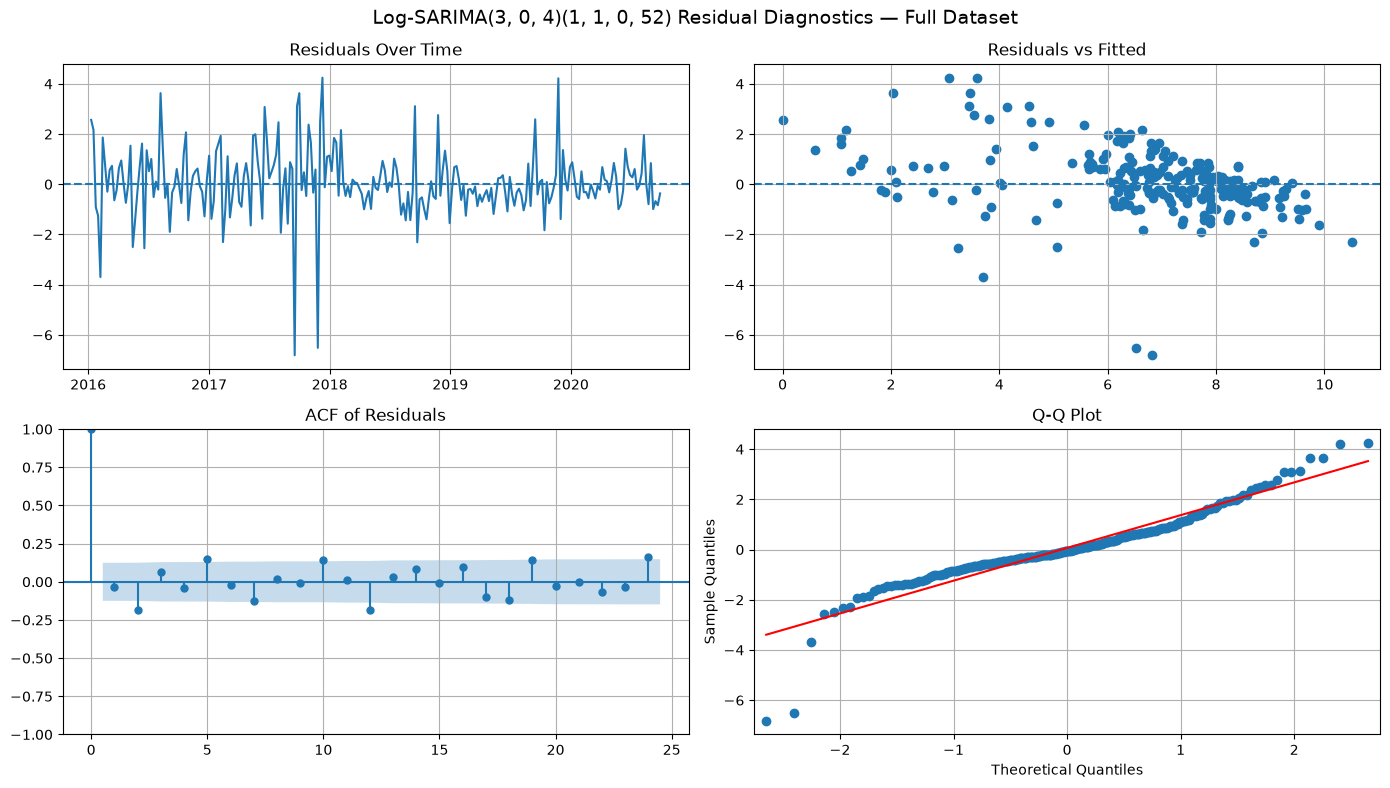

Ljung-Box Test:


,lb_stat,lb_pvalue
10,25.226639,0.004932
20,51.280885,0.000145


,lb_stat,lb_pvalue
10,25.226639,0.004932
20,51.280885,0.000145
30,67.651009,0.000099


In [32]:
residual_diagnostics(
    best_log_sarima.resid,
    fitted_values=best_log_sarima.fittedvalues,
    title=f"Log-SARIMA{best_log_sarima_order}{best_log_sarima_seasonal_order} Residual Diagnostics — Full Dataset"
)

display(
    acorr_ljungbox(
        pd.Series(best_log_sarima.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [33]:
sarima_results = []

def add_sarima_result(model_name, order, seasonal_order, y_true, y_pred, fitted_model=None):
    metrics = compute_metrics(y_true, y_pred)
    
    sarima_results.append({
        "Model": model_name,
        "Order": str(order),
        "Seasonal_Order": str(seasonal_order),
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R2": metrics["R2"],
        "nRMSE": metrics["nRMSE"],
        "MAPE": metrics["MAPE"],
        "SMAPE": metrics["SMAPE"],
        "AIC": fitted_model.aic if fitted_model is not None else np.nan,
        "BIC": fitted_model.bic if fitted_model is not None else np.nan
    })


add_sarima_result(
    model_name="SARIMA One-Shot",
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    y_true=test_series,
    y_pred=sarima_forecast,
    fitted_model=best_sarima
)

add_sarima_result(
    model_name="Rolling SARIMA",
    order=fast_sarima_order,
    seasonal_order=fast_sarima_seasonal_order,
    y_true=y_true_roll_sarima,
    y_pred=y_pred_roll_sarima,
    fitted_model=None
)

add_sarima_result(
    model_name="Log-SARIMA One-Shot",
    order=best_log_sarima_order,
    seasonal_order=best_log_sarima_seasonal_order,
    y_true=test_series,
    y_pred=log_sarima_forecast_original,
    fitted_model=best_log_sarima
)

sarima_results_df = pd.DataFrame(sarima_results)
sarima_results_df = sarima_results_df.sort_values("RMSE").reset_index(drop=True)

sarima_results_df

,Model,Order,Seasonal_Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-SARIMA One-Shot,"(3, 0, 4)","(1, 1, 0, 52)",2380.580771,1629.138171,0.283091,0.77149,1622.932213,67.715898,387.278762,413.753543
1,SARIMA One-Shot,"(3, 0, 2)","(1, 1, 0, 52)",2440.321915,1734.740522,0.246657,0.79085,1421.298491,79.931037,2475.749162,2496.340659
2,Rolling SARIMA,"(3, 0, 2)","(1, 1, 0, 52)",89631.243831,13277.442358,-1430.727221,33.73173,599.057030,129.955076,NaN,NaN


In [34]:
sarima_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Model,Order,Seasonal_Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-SARIMA One-Shot,"(3, 0, 4)","(1, 1, 0, 52)",2380.58,1629.14,0.283,0.771,1622.93,67.72,387.28,413.75
1,SARIMA One-Shot,"(3, 0, 2)","(1, 1, 0, 52)",2440.32,1734.74,0.247,0.791,1421.30,79.93,2475.75,2496.34
2,Rolling SARIMA,"(3, 0, 2)","(1, 1, 0, 52)",89631.24,13277.44,-1430.727,33.732,599.06,129.96,nan,nan


## ETS

In [35]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_results = []
ets_fits = {}
ets_forecasts = {}

ets_configs = [
    {"trend": None, "seasonal": None, "damped_trend": False, "name": "ETS Simple"},
    {"trend": "add", "seasonal": None, "damped_trend": False, "name": "ETS Additive Trend"},
    {"trend": "add", "seasonal": None, "damped_trend": True, "name": "ETS Damped Trend"},
    {"trend": None, "seasonal": "add", "damped_trend": False, "name": "ETS Additive Seasonality"},
    {"trend": "add", "seasonal": "add", "damped_trend": False, "name": "ETS Add Trend + Add Season"},
    {"trend": "add", "seasonal": "add", "damped_trend": True, "name": "ETS Damped Trend + Add Season"},
]

for config in ets_configs:
    try:
        model = ExponentialSmoothing(
            train_series,
            trend=config["trend"],
            seasonal=config["seasonal"],
            seasonal_periods=52 if config["seasonal"] is not None else None,
            damped_trend=config["damped_trend"],
            initialization_method="estimated"
        )

        fitted = model.fit(optimized=True)
        forecast = fitted.forecast(len(test_series))
        forecast.index = test_series.index
        forecast = np.maximum(forecast, 0)

        metrics = compute_metrics(test_series, forecast)

        ets_results.append({
            "Model": config["name"],
            "Trend": config["trend"],
            "Seasonal": config["seasonal"],
            "Damped_Trend": config["damped_trend"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        ets_fits[config["name"]] = fitted
        ets_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

ets_results_df = pd.DataFrame(ets_results).sort_values("RMSE").reset_index(drop=True)
ets_results_df

ETS Simple {'RMSE': np.float64(3919.008701760593), 'MAE': 2784.0635309831564, 'R2': -0.9429021127180961, 'nRMSE': np.float64(1.2700576516449837), 'MAPE': np.float64(356.7926083900669), 'SMAPE': np.float64(136.8556989819882)}
ETS Additive Trend {'RMSE': np.float64(3893.021810449103), 'MAE': 2750.2824746530437, 'R2': -0.9172208291743389, 'nRMSE': np.float64(1.261635917307472), 'MAPE': np.float64(423.30248277427495), 'SMAPE': np.float64(131.17048932556443)}
ETS Damped Trend {'RMSE': np.float64(3908.2130802587776), 'MAE': 2770.647595749417, 'R2': -0.9322127022472768, 'nRMSE': np.float64(1.2665590470906014), 'MAPE': np.float64(378.22760628952483), 'SMAPE': np.float64(134.66530409777883)}
ETS Additive Seasonality {'RMSE': np.float64(2171.2701708333416), 'MAE': 1521.3058263663459, 'R2': 0.4036157068741417, 'nRMSE': np.float64(0.7036570990558257), 'MAPE': np.float64(1510.0298964558885), 'SMAPE': np.float64(71.55798921229675)}
ETS Add Trend + Add Season {'RMSE': np.float64(2068.416548852991), '

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,2068.416549,1411.019996,0.458779,0.670325,1942.493336,54.901599,3580.654635,3777.180382
1,ETS Additive Seasonality,NaN,add,False,2171.270171,1521.305826,0.403616,0.703657,1510.029896,71.557989,3576.802093,3766.309063
2,ETS Damped Trend + Add Season,add,add,True,2177.037952,1533.681540,0.400443,0.705526,1535.398893,72.472647,3582.713654,3782.748789
3,ETS Additive Trend,add,NaN,False,3893.021810,2750.282475,-0.917221,1.261636,423.302483,131.170489,3555.429561,3569.467114
4,ETS Damped Trend,add,NaN,True,3908.213080,2770.647596,-0.932213,1.266559,378.227606,134.665304,3557.269223,3574.816165
5,ETS Simple,NaN,NaN,False,3919.008702,2784.063531,-0.942902,1.270058,356.792608,136.855699,3551.430637,3558.449414


In [36]:
ets_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,2068.42,1411.02,0.459,0.670,1942.49,54.90,3580.65,3777.18
1,ETS Additive Seasonality,nan,add,False,2171.27,1521.31,0.404,0.704,1510.03,71.56,3576.80,3766.31
2,ETS Damped Trend + Add Season,add,add,True,2177.04,1533.68,0.400,0.706,1535.40,72.47,3582.71,3782.75
3,ETS Additive Trend,add,nan,False,3893.02,2750.28,-0.917,1.262,423.30,131.17,3555.43,3569.47
4,ETS Damped Trend,add,nan,True,3908.21,2770.65,-0.932,1.267,378.23,134.67,3557.27,3574.82
5,ETS Simple,nan,nan,False,3919.01,2784.06,-0.943,1.270,356.79,136.86,3551.43,3558.45


In [37]:
best_ets_name = ets_results_df.iloc[0]["Model"]
best_ets_model = ets_fits[best_ets_name]
best_ets_forecast = ets_forecasts[best_ets_name]

print("Best ETS model:", best_ets_name)
display(ets_results_df.iloc[[0]])

Best ETS model: ETS Add Trend + Add Season


,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,2068.416549,1411.019996,0.458779,0.670325,1942.493336,54.901599,3580.654635,3777.180382


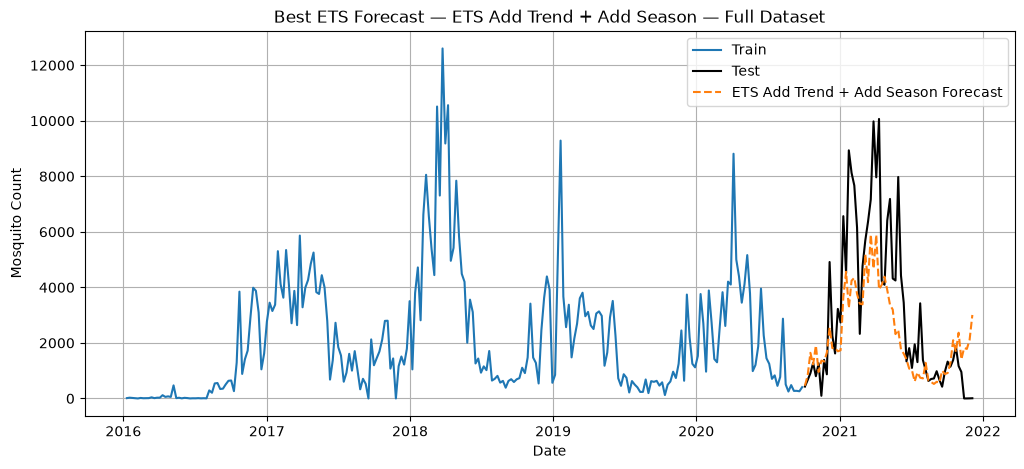

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_ets_forecast.index,
    best_ets_forecast,
    label=f"{best_ets_name} Forecast",
    linestyle="--"
)

plt.title(f"Best ETS Forecast — {best_ets_name} — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

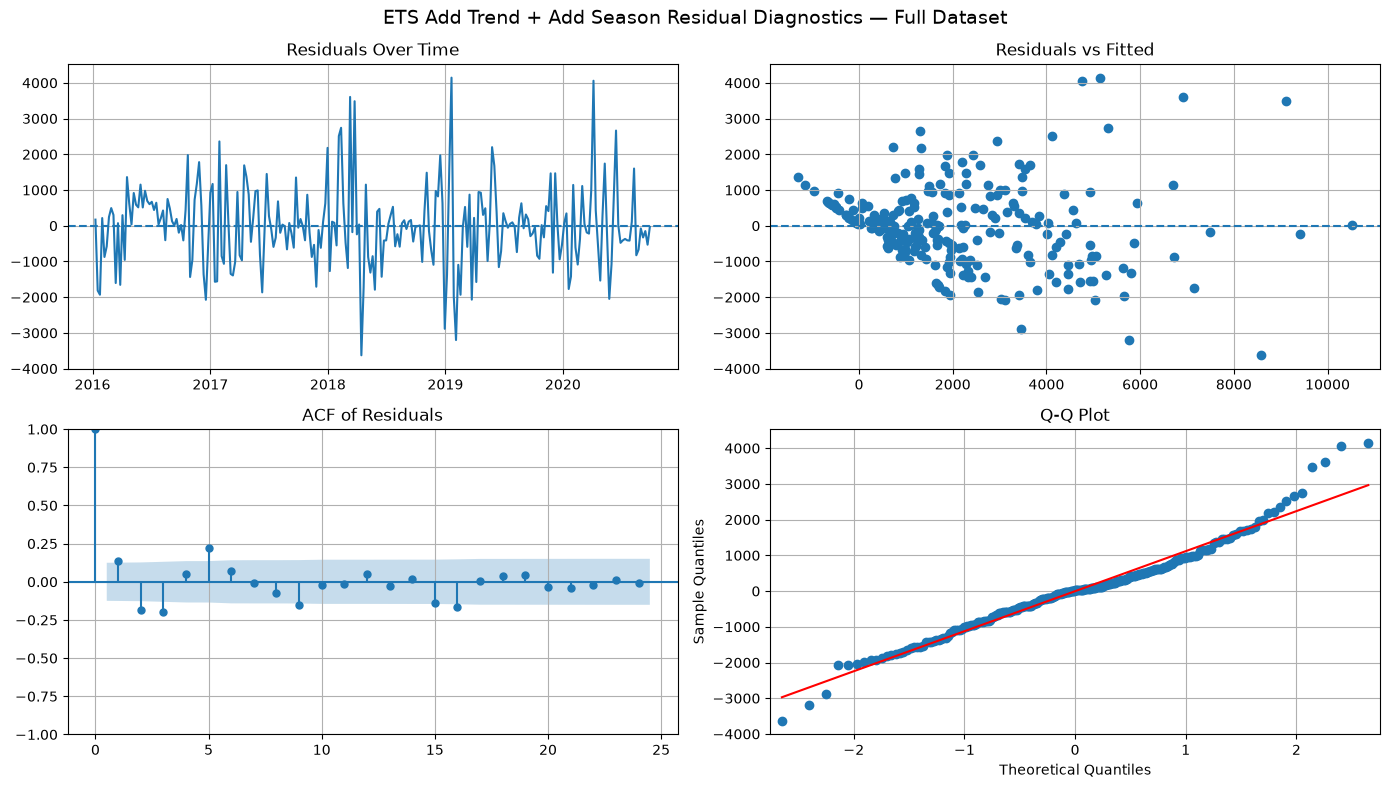

Ljung-Box Test:


,lb_stat,lb_pvalue
10,43.981668,0.000003
20,58.262482,0.000013


,lb_stat,lb_pvalue
10,43.981668,0.000003
20,58.262482,0.000013
30,67.104703,0.000117


In [39]:
residual_diagnostics(
    best_ets_model.resid,
    fitted_values=best_ets_model.fittedvalues,
    title=f"{best_ets_name} Residual Diagnostics — Full Dataset"
)

display(
    acorr_ljungbox(
        pd.Series(best_ets_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [40]:
log_train_series = np.log1p(train_series)

log_ets_results = []
log_ets_fits = {}
log_ets_forecasts = {}

for config in ets_configs:
    try:
        model = ExponentialSmoothing(
            log_train_series,
            trend=config["trend"],
            seasonal=config["seasonal"],
            seasonal_periods=52 if config["seasonal"] is not None else None,
            damped_trend=config["damped_trend"],
            initialization_method="estimated"
        )

        fitted = model.fit(optimized=True)

        log_forecast = fitted.forecast(len(test_series))
        log_forecast.index = test_series.index

        forecast_original = np.expm1(log_forecast)
        forecast_original = np.maximum(forecast_original, 0)

        metrics = compute_metrics(test_series, forecast_original)

        log_ets_results.append({
            "Model": "Log-" + config["name"],
            "Trend": config["trend"],
            "Seasonal": config["seasonal"],
            "Damped_Trend": config["damped_trend"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        log_ets_fits["Log-" + config["name"]] = fitted
        log_ets_forecasts["Log-" + config["name"]] = forecast_original

        print("Log-" + config["name"], metrics)

    except Exception as e:
        print("Failed:", "Log-" + config["name"], "|", e)

log_ets_results_df = pd.DataFrame(log_ets_results).sort_values("RMSE").reset_index(drop=True)
log_ets_results_df

Log-ETS Simple {'RMSE': np.float64(3928.348746678877), 'MAE': 2795.294216158864, 'R2': -0.952174058108155, 'nRMSE': np.float64(1.2730845383956677), 'MAPE': np.float64(346.7451346805072), 'SMAPE': np.float64(138.5737947162242)}
Log-ETS Additive Trend {'RMSE': np.float64(3828.038128162967), 'MAE': 2661.66689712526, 'R2': -0.8537491912398321, 'nRMSE': np.float64(1.2405762491106405), 'MAPE': np.float64(680.5571791527398), 'SMAPE': np.float64(117.60937738114643)}
Log-ETS Damped Trend {'RMSE': np.float64(3922.0955641913624), 'MAE': 2787.6063668354777, 'R2': -0.9459640265802438, 'nRMSE': np.float64(1.2710580304520052), 'MAPE': np.float64(358.0860065310619), 'SMAPE': np.float64(137.3090346974908)}
Log-ETS Additive Seasonality {'RMSE': np.float64(3229.064166251298), 'MAE': 2277.375130395306, 'R2': -0.31902131994199956, 'nRMSE': np.float64(1.046463012485197), 'MAPE': np.float64(910.6586720343364), 'SMAPE': np.float64(102.5501395772459)}
Log-ETS Add Trend + Add Season {'RMSE': np.float64(2771.161

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-ETS Add Trend + Add Season,add,add,False,2771.161676,1935.459362,0.028546,0.898068,2905.685297,73.902956,55.834686,252.360433
1,Log-ETS Damped Trend + Add Season,add,add,True,3113.393894,2188.680916,-0.226215,1.008977,1058.265996,96.892457,54.495020,254.530155
2,Log-ETS Additive Seasonality,NaN,add,False,3229.064166,2277.375130,-0.319021,1.046463,910.658672,102.550140,52.593649,242.100619
3,Log-ETS Additive Trend,add,NaN,False,3828.038128,2661.666897,-0.853749,1.240576,680.557179,117.609377,22.870114,36.907667
4,Log-ETS Damped Trend,add,NaN,True,3922.095564,2787.606367,-0.945964,1.271058,358.086007,137.309035,23.386468,40.933410
5,Log-ETS Simple,NaN,NaN,False,3928.348747,2795.294216,-0.952174,1.273085,346.745135,138.573795,19.103783,26.122560


In [41]:
all_ets_results_df = pd.concat(
    [ets_results_df, log_ets_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

all_ets_results_df

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,2068.416549,1411.019996,0.458779,0.670325,1942.493336,54.901599,3580.654635,3777.180382
1,ETS Additive Seasonality,NaN,add,False,2171.270171,1521.305826,0.403616,0.703657,1510.029896,71.557989,3576.802093,3766.309063
2,ETS Damped Trend + Add Season,add,add,True,2177.037952,1533.681540,0.400443,0.705526,1535.398893,72.472647,3582.713654,3782.748789
3,Log-ETS Add Trend + Add Season,add,add,False,2771.161676,1935.459362,0.028546,0.898068,2905.685297,73.902956,55.834686,252.360433
4,Log-ETS Damped Trend + Add Season,add,add,True,3113.393894,2188.680916,-0.226215,1.008977,1058.265996,96.892457,54.495020,254.530155
5,Log-ETS Additive Seasonality,NaN,add,False,3229.064166,2277.375130,-0.319021,1.046463,910.658672,102.550140,52.593649,242.100619
6,Log-ETS Additive Trend,add,NaN,False,3828.038128,2661.666897,-0.853749,1.240576,680.557179,117.609377,22.870114,36.907667
7,ETS Additive Trend,add,NaN,False,3893.021810,2750.282475,-0.917221,1.261636,423.302483,131.170489,3555.429561,3569.467114
8,ETS Damped Trend,add,NaN,True,3908.213080,2770.647596,-0.932213,1.266559,378.227606,134.665304,3557.269223,3574.816165
9,ETS Simple,NaN,NaN,False,3919.008702,2784.063531,-0.942902,1.270058,356.792608,136.855699,3551.430637,3558.449414


In [42]:
best_overall_ets_name = all_ets_results_df.iloc[0]["Model"]

if best_overall_ets_name.startswith("Log-"):
    best_overall_ets_model = log_ets_fits[best_overall_ets_name]
    best_overall_ets_forecast = log_ets_forecasts[best_overall_ets_name]
else:
    best_overall_ets_model = ets_fits[best_overall_ets_name]
    best_overall_ets_forecast = ets_forecasts[best_overall_ets_name]

print("Best overall ETS model:", best_overall_ets_name)
display(all_ets_results_df.iloc[[0]])

Best overall ETS model: ETS Add Trend + Add Season


,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,2068.416549,1411.019996,0.458779,0.670325,1942.493336,54.901599,3580.654635,3777.180382


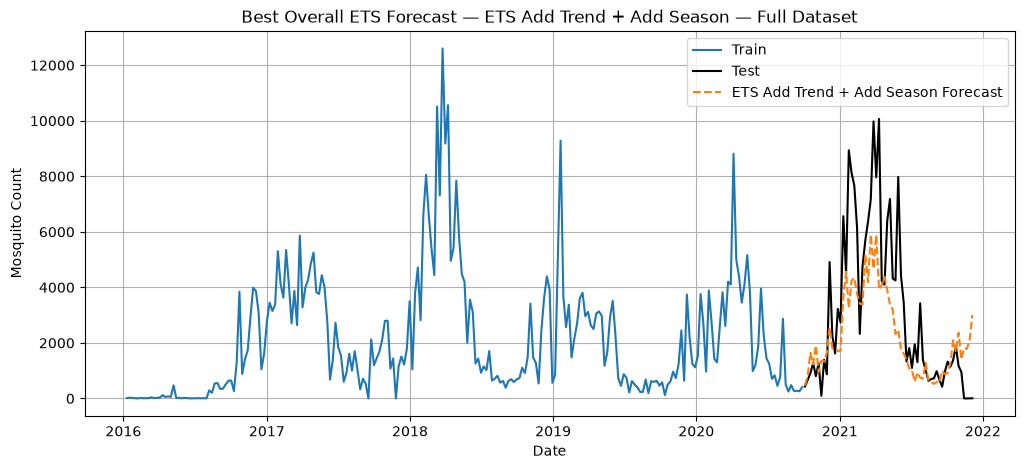

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_overall_ets_forecast.index,
    best_overall_ets_forecast,
    label=f"{best_overall_ets_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Overall ETS Forecast — {best_overall_ets_name} — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

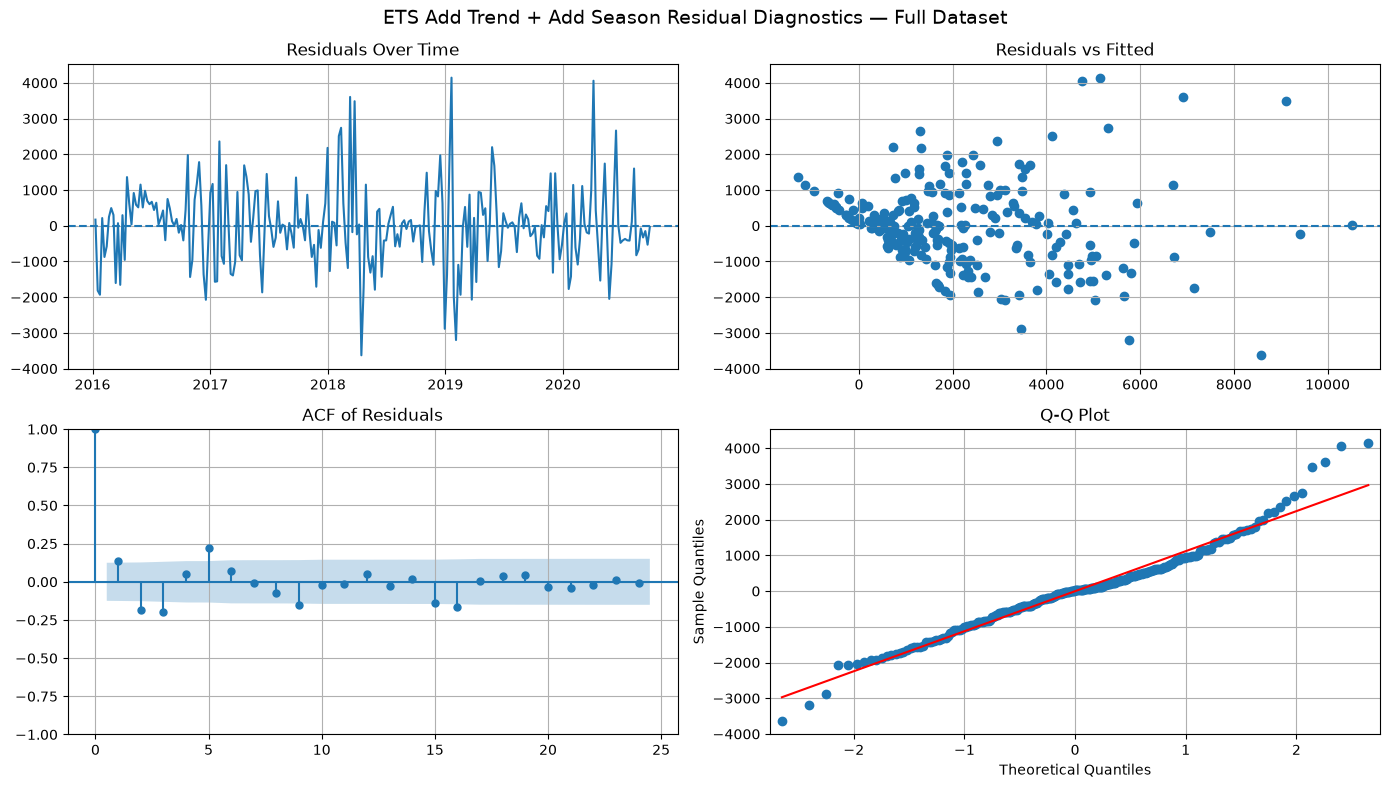

Ljung-Box Test:


,lb_stat,lb_pvalue
10,43.981668,0.000003
20,58.262482,0.000013


,lb_stat,lb_pvalue
10,43.981668,0.000003
20,58.262482,0.000013
30,67.104703,0.000117


In [44]:
residual_diagnostics(
    best_overall_ets_model.resid,
    fitted_values=best_overall_ets_model.fittedvalues,
    title=f"{best_overall_ets_name} Residual Diagnostics — Full Dataset"
)

display(
    acorr_ljungbox(
        pd.Series(best_overall_ets_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [45]:
add_result(
    best_overall_ets_name,
    test_series,
    best_overall_ets_forecast
)

{'RMSE': np.float64(2068.416548852991),
 'MAE': 1411.019996095216,
 'R2': 0.45877920792309235,
 'nRMSE': np.float64(0.6703246827392046),
 'MAPE': np.float64(1942.4933360517475),
 'SMAPE': np.float64(54.90159863165732)}

## STRUCTURAL STATE SPACE MODEL

In [46]:
structural_results = []
structural_fits = {}
structural_forecasts = {}

structural_configs = [
    {"level": "local level", "seasonal": None, "name": "Local Level"},
    {"level": "local linear trend", "seasonal": None, "name": "Local Linear Trend"},
    {"level": "local level", "seasonal": 52, "name": "Local Level + Seasonal"},
    {"level": "local linear trend", "seasonal": 52, "name": "Local Linear Trend + Seasonal"},
]

for config in structural_configs:
    try:
        model = UnobservedComponents(
            train_series,
            level=config["level"],
            seasonal=config["seasonal"]
        )

        fitted = model.fit(disp=False)

        forecast = fitted.forecast(steps=len(test_series))
        forecast.index = test_series.index
        forecast = np.maximum(forecast, 0)

        metrics = compute_metrics(test_series, forecast)

        structural_results.append({
            "Model": config["name"],
            "Level": config["level"],
            "Seasonal": config["seasonal"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        structural_fits[config["name"]] = fitted
        structural_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

structural_results_df = pd.DataFrame(structural_results).sort_values("RMSE").reset_index(drop=True)
structural_results_df

Local Level {'RMSE': np.float64(3919.313348494961), 'MAE': 2784.430291382824, 'R2': -0.9432041900211607, 'nRMSE': np.float64(1.2701563804168434), 'MAPE': np.float64(356.4644881181772), 'SMAPE': np.float64(136.91137359344845)}
Local Linear Trend {'RMSE': np.float64(3893.3241285237355), 'MAE': 2750.638442300165, 'R2': -0.9175186096868437, 'nRMSE': np.float64(1.2617338914160126), 'MAPE': np.float64(422.9074892797559), 'SMAPE': np.float64(131.22111234405324)}
Local Level + Seasonal {'RMSE': np.float64(3689.037303389134), 'MAE': 2634.940125452367, 'R2': -0.7215694947156035, 'nRMSE': np.float64(1.1955293827922113), 'MAPE': np.float64(592.909655978923), 'SMAPE': np.float64(130.1718161007795)}
Local Linear Trend + Seasonal {'RMSE': np.float64(3675.099831123497), 'MAE': 2608.0814755735205, 'R2': -0.7085856190366266, 'nRMSE': np.float64(1.1910125790179278), 'MAPE': np.float64(671.3379437814615), 'SMAPE': np.float64(124.5366505658485)}


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Local Linear Trend + Seasonal,local linear trend,52.0,3675.099831,2608.081476,-0.708586,1.191013,671.337944,124.536651,3391.986409,3405.057841
1,Local Level + Seasonal,local level,52.0,3689.037303,2634.940125,-0.721569,1.195529,592.909656,130.171816,3405.238694,3415.057693
2,Local Linear Trend,local linear trend,NaN,3893.324129,2750.638442,-0.917519,1.261734,422.907489,131.221112,4227.823394,4238.327169
3,Local Level,local level,NaN,3919.313348,2784.430291,-0.943204,1.270156,356.464488,136.911374,4236.219212,4243.229875


In [47]:
log_structural_results = []
log_structural_fits = {}
log_structural_forecasts = {}

log_train_series = np.log1p(train_series)

for config in structural_configs:
    try:
        model = UnobservedComponents(
            log_train_series,
            level=config["level"],
            seasonal=config["seasonal"]
        )

        fitted = model.fit(disp=False)

        log_forecast = fitted.forecast(steps=len(test_series))
        log_forecast.index = test_series.index

        forecast_original = np.expm1(log_forecast)
        forecast_original = np.maximum(forecast_original, 0)

        metrics = compute_metrics(test_series, forecast_original)

        model_name = "Log-" + config["name"]

        log_structural_results.append({
            "Model": model_name,
            "Level": config["level"],
            "Seasonal": config["seasonal"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        log_structural_fits[model_name] = fitted
        log_structural_forecasts[model_name] = forecast_original

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", "Log-" + config["name"], "|", e)

log_structural_results_df = pd.DataFrame(log_structural_results).sort_values("RMSE").reset_index(drop=True)
log_structural_results_df

Log-Local Level {'RMSE': np.float64(3928.4870174398247), 'MAE': 2795.4602647046854, 'R2': -0.952311486508953, 'nRMSE': np.float64(1.2731293486656377), 'MAPE': np.float64(346.59658021810793), 'SMAPE': np.float64(138.59940466980245)}
Log-Local Linear Trend {'RMSE': np.float64(3903.021119828795), 'MAE': 2761.966835620694, 'R2': -0.927082322670552, 'nRMSE': np.float64(1.2648764560138896), 'MAPE': np.float64(415.15706727876767), 'SMAPE': np.float64(132.7803439670679)}
Log-Local Level + Seasonal {'RMSE': np.float64(3223.575830481835), 'MAE': 2272.8635740944073, 'R2': -0.3145413347979813, 'nRMSE': np.float64(1.0446843731992796), 'MAPE': np.float64(915.203240366953), 'SMAPE': np.float64(102.22571199536412)}
Log-Local Linear Trend + Seasonal {'RMSE': np.float64(3125.0616521423653), 'MAE': 2194.9127460244054, 'R2': -0.23542289157251894, 'nRMSE': np.float64(1.012758267513586), 'MAPE': np.float64(1114.904944623657), 'SMAPE': np.float64(95.92847836848141)}


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-Local Linear Trend + Seasonal,local linear trend,52.0,3125.061652,2194.912746,-0.235423,1.012758,1114.904945,95.928478,642.198330,655.269763
1,Log-Local Level + Seasonal,local level,52.0,3223.575830,2272.863574,-0.314541,1.044684,915.203240,102.225712,643.249435,653.068434
2,Log-Local Linear Trend,local linear trend,NaN,3903.021120,2761.966836,-0.927082,1.264876,415.157067,132.780344,725.693584,736.197359
3,Log-Local Level,local level,NaN,3928.487017,2795.460265,-0.952311,1.273129,346.596580,138.599405,718.588851,725.599514


In [48]:
all_structural_results_df = pd.concat(
    [structural_results_df, log_structural_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

all_structural_results_df

,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-Local Linear Trend + Seasonal,local linear trend,52.0,3125.061652,2194.912746,-0.235423,1.012758,1114.904945,95.928478,642.198330,655.269763
1,Log-Local Level + Seasonal,local level,52.0,3223.575830,2272.863574,-0.314541,1.044684,915.203240,102.225712,643.249435,653.068434
2,Local Linear Trend + Seasonal,local linear trend,52.0,3675.099831,2608.081476,-0.708586,1.191013,671.337944,124.536651,3391.986409,3405.057841
3,Local Level + Seasonal,local level,52.0,3689.037303,2634.940125,-0.721569,1.195529,592.909656,130.171816,3405.238694,3415.057693
4,Local Linear Trend,local linear trend,NaN,3893.324129,2750.638442,-0.917519,1.261734,422.907489,131.221112,4227.823394,4238.327169
5,Log-Local Linear Trend,local linear trend,NaN,3903.021120,2761.966836,-0.927082,1.264876,415.157067,132.780344,725.693584,736.197359
6,Local Level,local level,NaN,3919.313348,2784.430291,-0.943204,1.270156,356.464488,136.911374,4236.219212,4243.229875
7,Log-Local Level,local level,NaN,3928.487017,2795.460265,-0.952311,1.273129,346.596580,138.599405,718.588851,725.599514


In [49]:
best_structural_name = all_structural_results_df.iloc[0]["Model"]

if best_structural_name.startswith("Log-"):
    best_structural_model = log_structural_fits[best_structural_name]
    best_structural_forecast = log_structural_forecasts[best_structural_name]
else:
    best_structural_model = structural_fits[best_structural_name]
    best_structural_forecast = structural_forecasts[best_structural_name]

print("Best Structural Model:", best_structural_name)
display(all_structural_results_df.iloc[[0]])

Best Structural Model: Log-Local Linear Trend + Seasonal


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-Local Linear Trend + Seasonal,local linear trend,52.0,3125.061652,2194.912746,-0.235423,1.012758,1114.904945,95.928478,642.19833,655.269763


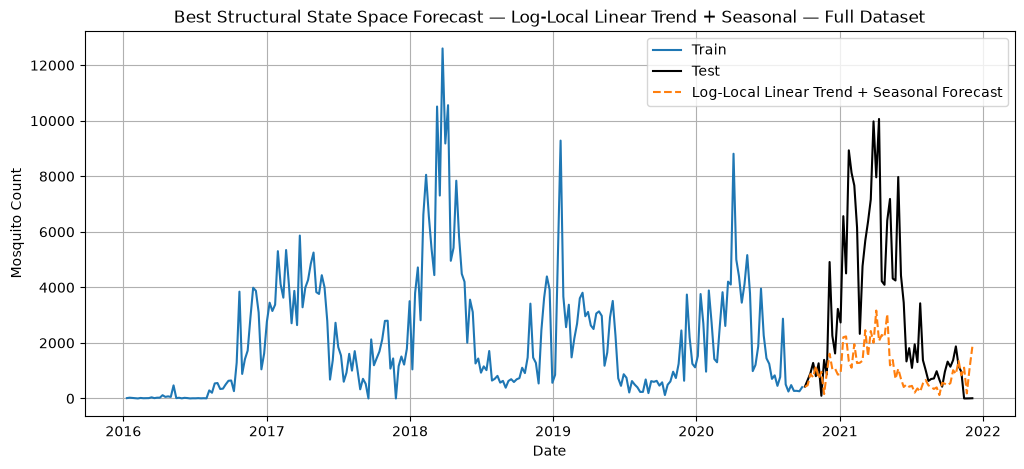

In [50]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_structural_forecast.index,
    best_structural_forecast,
    label=f"{best_structural_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Structural State Space Forecast — {best_structural_name} — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

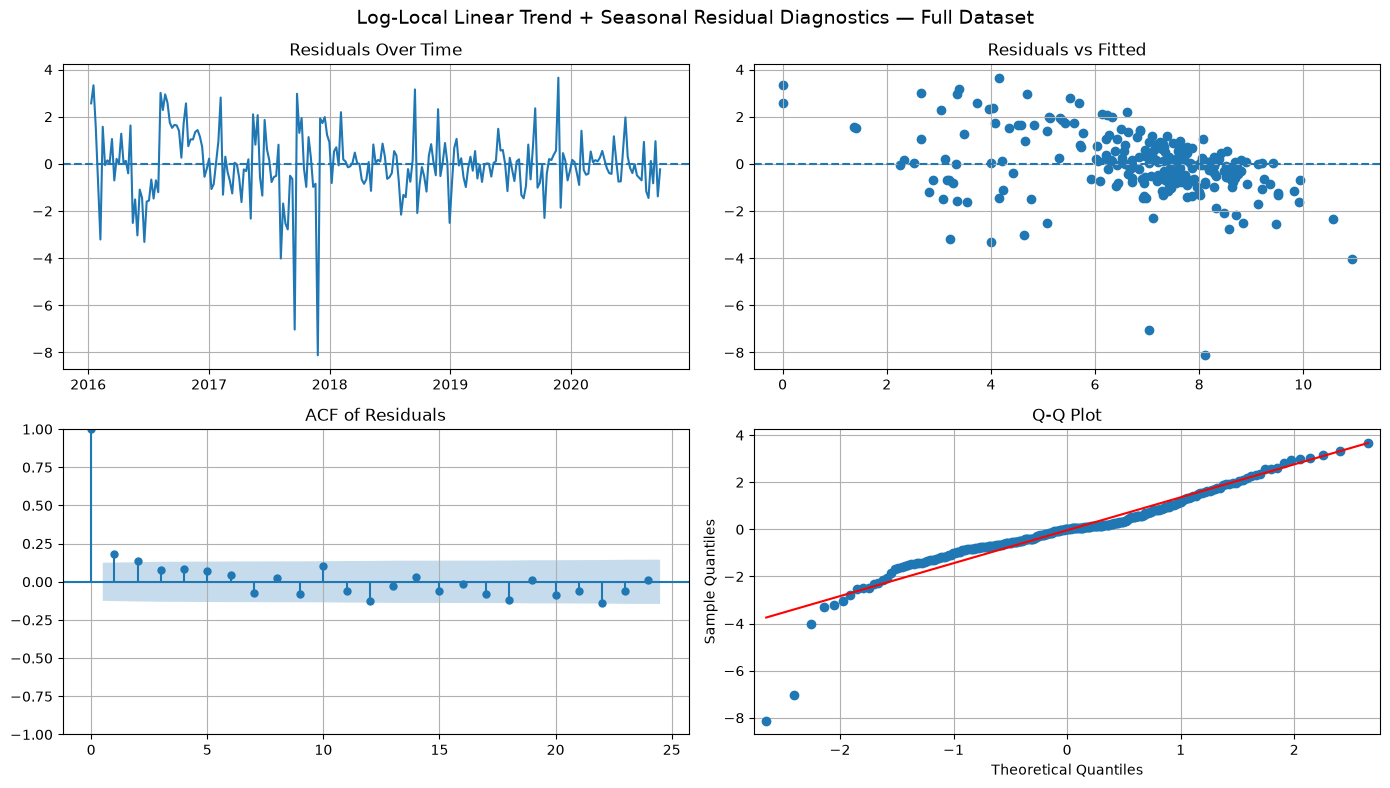

Ljung-Box Test:


,lb_stat,lb_pvalue
10,24.212657,0.007056
20,38.706133,0.007251


,lb_stat,lb_pvalue
10,24.212657,0.007056
20,38.706133,0.007251
30,51.804352,0.007995


{'RMSE': np.float64(3125.0616521423653),
 'MAE': 2194.9127460244054,
 'R2': -0.23542289157251894,
 'nRMSE': np.float64(1.012758267513586),
 'MAPE': np.float64(1114.904944623657),
 'SMAPE': np.float64(95.92847836848141)}

In [51]:
residual_diagnostics(
    best_structural_model.resid,
    fitted_values=best_structural_model.fittedvalues,
    title=f"{best_structural_name} Residual Diagnostics — Full Dataset"
)

display(
    acorr_ljungbox(
        pd.Series(best_structural_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

add_result(
    best_structural_name,
    test_series,
    best_structural_forecast
)

## PROPHET

In [52]:
def prepare_prophet_df(ts):
    df = ts.reset_index()
    df.columns = ["ds", "y"]
    return df

prophet_df = prepare_prophet_df(ts_series)

train_prophet = prophet_df.iloc[:train_size].copy()
test_prophet = prophet_df.iloc[train_size:].copy()

train_prophet.head()

,ds,y
0,2016-01-10,12
1,2016-01-17,27
2,2016-01-24,18
3,2016-01-31,11
4,2016-02-07,0


In [53]:
prophet_configs = [
    {
        "name": "Prophet Default",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Flexible Trend",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.5,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Conservative Trend",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.01,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Multiplicative Seasonality",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "multiplicative",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Strong Seasonality",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 20.0
    },
]

In [54]:
prophet_results = []
prophet_models = {}
prophet_forecasts = {}

for config in prophet_configs:
    try:
        model = Prophet(
            yearly_seasonality=config["yearly_seasonality"],
            weekly_seasonality=config["weekly_seasonality"],
            daily_seasonality=False,
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"],
            seasonality_prior_scale=config["seasonality_prior_scale"]
        )

        model.fit(train_prophet)

        future = model.make_future_dataframe(
            periods=len(test_prophet),
            freq="W"
        )

        forecast = model.predict(future)

        test_forecast = forecast.iloc[train_size:]["yhat"].values
        test_forecast = np.maximum(test_forecast, 0)

        metrics = compute_metrics(test_series.values, test_forecast)

        prophet_results.append({
            "Model": config["name"],
            "Seasonality_Mode": config["seasonality_mode"],
            "Changepoint_Prior": config["changepoint_prior_scale"],
            "Seasonality_Prior": config["seasonality_prior_scale"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        prophet_models[config["name"]] = model
        prophet_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

prophet_results_df = pd.DataFrame(prophet_results).sort_values("RMSE").reset_index(drop=True)
prophet_results_df

13:48:34 - cmdstanpy - INFO - Chain [1] start processing
13:48:35 - cmdstanpy - INFO - Chain [1] done processing
13:48:35 - cmdstanpy - INFO - Chain [1] start processing
13:48:35 - cmdstanpy - INFO - Chain [1] done processing


Prophet Default {'RMSE': np.float64(2586.7323985990342), 'MAE': 1915.70824116048, 'R2': 0.15354968647460376, 'nRMSE': np.float64(0.8382985406801426), 'MAPE': np.float64(825.8391251596306), 'SMAPE': np.float64(114.679556950241)}
Prophet Flexible Trend {'RMSE': np.float64(1905.8527595680844), 'MAE': 1377.3542046371522, 'R2': 0.5405088452488357, 'nRMSE': np.float64(0.6176416191958792), 'MAPE': np.float64(2337.9475915600483), 'SMAPE': np.float64(53.396839104350114)}


13:48:35 - cmdstanpy - INFO - Chain [1] start processing
13:48:35 - cmdstanpy - INFO - Chain [1] done processing
13:48:35 - cmdstanpy - INFO - Chain [1] start processing
13:48:35 - cmdstanpy - INFO - Chain [1] done processing


Prophet Conservative Trend {'RMSE': np.float64(2018.6246565148926), 'MAE': 1546.198459534467, 'R2': 0.4845226202739128, 'nRMSE': np.float64(0.6541883128899937), 'MAPE': np.float64(2575.6700348962436), 'SMAPE': np.float64(60.2662991777413)}
Prophet Multiplicative Seasonality {'RMSE': np.float64(2519.1000857308086), 'MAE': 1761.1489739412687, 'R2': 0.19723337145377906, 'nRMSE': np.float64(0.8163805142113194), 'MAPE': np.float64(932.62811104197), 'SMAPE': np.float64(76.18499834781609)}


13:48:35 - cmdstanpy - INFO - Chain [1] start processing
13:48:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet Strong Seasonality {'RMSE': np.float64(2573.14938763221), 'MAE': 1904.3598397732183, 'R2': 0.1624158200146858, 'nRMSE': np.float64(0.8338966093950596), 'MAPE': np.float64(849.5432764944436), 'SMAPE': np.float64(113.45470538968188)}


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Flexible Trend,additive,0.50,10.0,1905.852760,1377.354205,0.540509,0.617642,2337.947592,53.396839
1,Prophet Conservative Trend,additive,0.01,10.0,2018.624657,1546.198460,0.484523,0.654188,2575.670035,60.266299
2,Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,2519.100086,1761.148974,0.197233,0.816381,932.628111,76.184998
3,Prophet Strong Seasonality,additive,0.05,20.0,2573.149388,1904.359840,0.162416,0.833897,849.543276,113.454705
4,Prophet Default,additive,0.05,10.0,2586.732399,1915.708241,0.153550,0.838299,825.839125,114.679557


Best Prophet model: Prophet Flexible Trend


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Flexible Trend,additive,0.5,10.0,1905.85276,1377.354205,0.540509,0.617642,2337.947592,53.396839


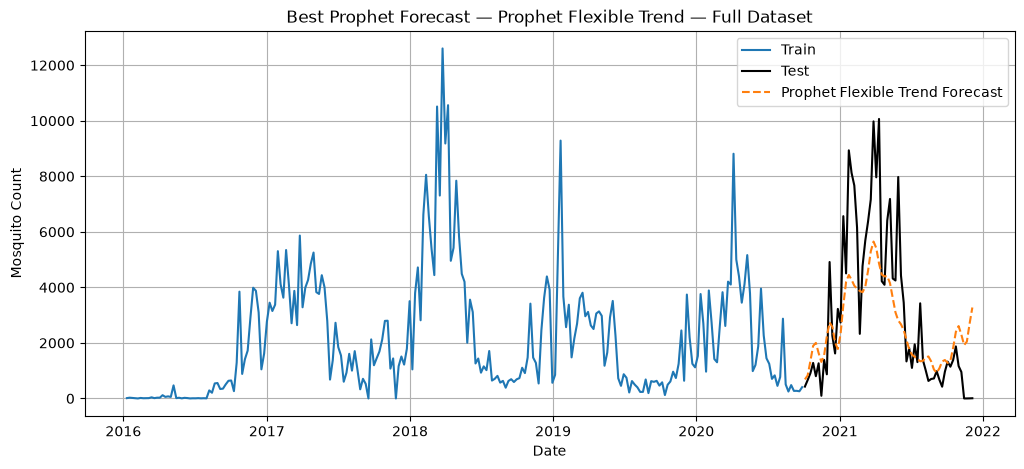

In [55]:
best_prophet_name = prophet_results_df.iloc[0]["Model"]
best_prophet_model = prophet_models[best_prophet_name]
best_prophet_forecast = prophet_forecasts[best_prophet_name]

print("Best Prophet model:", best_prophet_name)
display(prophet_results_df.iloc[[0]])

best_prophet_test_forecast = best_prophet_forecast.iloc[train_size:]["yhat"].values
best_prophet_test_forecast = np.maximum(best_prophet_test_forecast, 0)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    test_series.index,
    best_prophet_test_forecast,
    label=f"{best_prophet_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Prophet Forecast — {best_prophet_name} — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

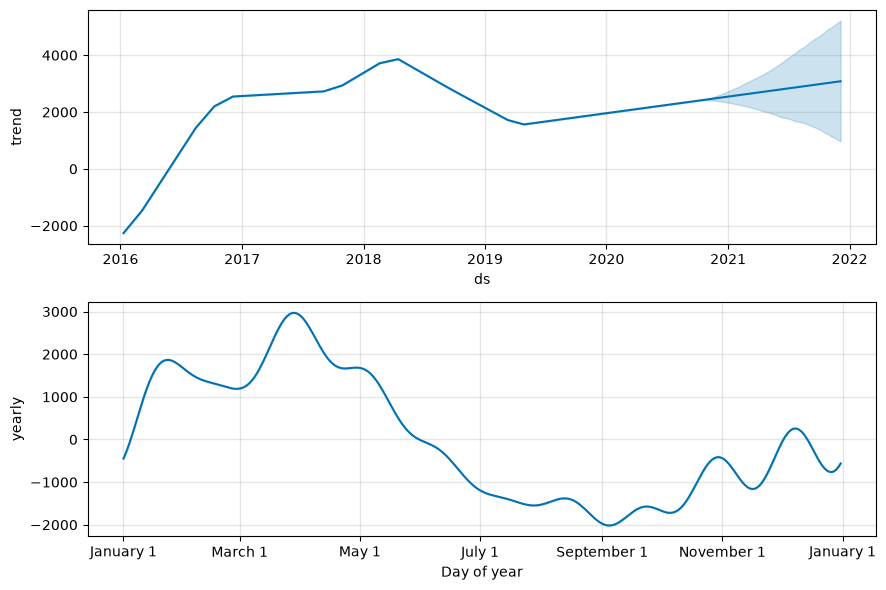

In [56]:
best_prophet_model.plot_components(best_prophet_forecast)
plt.show()

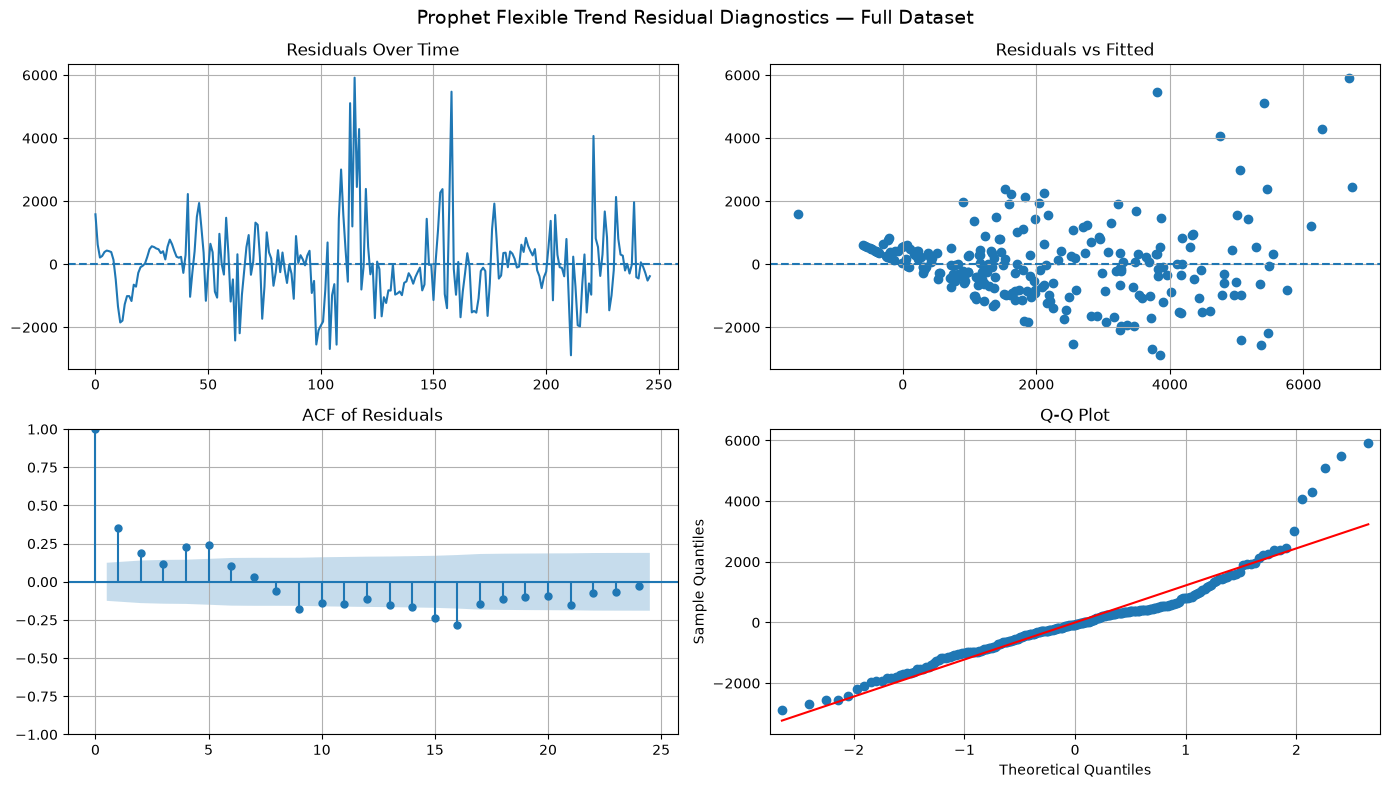

Ljung-Box Test:


,lb_stat,lb_pvalue
10,88.766290,9.404017e-15
20,160.076549,7.257555e-24


,lb_stat,lb_pvalue
10,88.766290,9.404017e-15
20,160.076549,7.257555e-24
30,172.478386,6.054194e-22


In [57]:
prophet_train_forecast = best_prophet_forecast.iloc[:train_size]

prophet_train_residuals = (
    train_prophet["y"].values - prophet_train_forecast["yhat"].values
)

residual_diagnostics(
    prophet_train_residuals,
    fitted_values=prophet_train_forecast["yhat"].values,
    title=f"{best_prophet_name} Residual Diagnostics — Full Dataset"
)

display(
    acorr_ljungbox(
        pd.Series(prophet_train_residuals).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [58]:
log_prophet_df = prophet_df.copy()
log_prophet_df["y"] = np.log1p(log_prophet_df["y"])

log_train_prophet = log_prophet_df.iloc[:train_size].copy()

log_prophet_results = []
log_prophet_models = {}
log_prophet_forecasts = {}

for config in prophet_configs:
    try:
        model_name = "Log-" + config["name"]

        model = Prophet(
            yearly_seasonality=config["yearly_seasonality"],
            weekly_seasonality=config["weekly_seasonality"],
            daily_seasonality=False,
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"],
            seasonality_prior_scale=config["seasonality_prior_scale"]
        )

        model.fit(log_train_prophet)

        future = model.make_future_dataframe(
            periods=len(test_prophet),
            freq="W"
        )

        forecast = model.predict(future)

        log_test_forecast = forecast.iloc[train_size:]["yhat"].values
        test_forecast_original = np.expm1(log_test_forecast)
        test_forecast_original = np.maximum(test_forecast_original, 0)

        metrics = compute_metrics(test_series.values, test_forecast_original)

        log_prophet_results.append({
            "Model": model_name,
            "Seasonality_Mode": config["seasonality_mode"],
            "Changepoint_Prior": config["changepoint_prior_scale"],
            "Seasonality_Prior": config["seasonality_prior_scale"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        log_prophet_models[model_name] = model
        log_prophet_forecasts[model_name] = forecast

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", model_name, "|", e)

log_prophet_results_df = pd.DataFrame(log_prophet_results).sort_values("RMSE").reset_index(drop=True)
log_prophet_results_df

13:48:37 - cmdstanpy - INFO - Chain [1] start processing
13:48:37 - cmdstanpy - INFO - Chain [1] done processing
13:48:37 - cmdstanpy - INFO - Chain [1] start processing
13:48:37 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Default {'RMSE': np.float64(2676.029769121589), 'MAE': 1875.2877656030694, 'R2': 0.09409982052398203, 'nRMSE': np.float64(0.8672376978330721), 'MAPE': np.float64(887.9099266404327), 'SMAPE': np.float64(77.8988142880084)}


13:48:37 - cmdstanpy - INFO - Chain [1] start processing
13:48:37 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Flexible Trend {'RMSE': np.float64(1875.5983574619472), 'MAE': 1354.3709037387755, 'R2': 0.5549814109668649, 'nRMSE': np.float64(0.6078368859546436), 'MAPE': np.float64(1324.1373424848255), 'SMAPE': np.float64(56.57851478886009)}
Log-Prophet Conservative Trend {'RMSE': np.float64(7942.705985021186), 'MAE': 6358.393673683565, 'R2': -6.980598057072102, 'nRMSE': np.float64(2.5740423864102993), 'MAPE': np.float64(10705.103547227682), 'SMAPE': np.float64(107.66613818851343)}


13:48:37 - cmdstanpy - INFO - Chain [1] start processing
13:48:37 - cmdstanpy - INFO - Chain [1] done processing
13:48:37 - cmdstanpy - INFO - Chain [1] start processing
13:48:38 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Multiplicative Seasonality {'RMSE': np.float64(2619.651174896621), 'MAE': 1822.7228357416086, 'R2': 0.13186873643720798, 'nRMSE': np.float64(0.8489667343232844), 'MAPE': np.float64(708.8761067342386), 'SMAPE': np.float64(77.58721710776956)}
Log-Prophet Strong Seasonality {'RMSE': np.float64(2791.623152781785), 'MAE': 1943.1089791886202, 'R2': 0.014147259411512403, 'nRMSE': np.float64(0.9046987683663456), 'MAPE': np.float64(756.6312766716653), 'SMAPE': np.float64(82.14498739805498)}


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Log-Prophet Flexible Trend,additive,0.50,10.0,1875.598357,1354.370904,0.554981,0.607837,1324.137342,56.578515
1,Log-Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,2619.651175,1822.722836,0.131869,0.848967,708.876107,77.587217
2,Log-Prophet Default,additive,0.05,10.0,2676.029769,1875.287766,0.094100,0.867238,887.909927,77.898814
3,Log-Prophet Strong Seasonality,additive,0.05,20.0,2791.623153,1943.108979,0.014147,0.904699,756.631277,82.144987
4,Log-Prophet Conservative Trend,additive,0.01,10.0,7942.705985,6358.393674,-6.980598,2.574042,10705.103547,107.666138


In [59]:
all_prophet_results_df = pd.concat(
    [prophet_results_df, log_prophet_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

display(all_prophet_results_df)

best_overall_prophet_name = all_prophet_results_df.iloc[0]["Model"]

if best_overall_prophet_name.startswith("Log-"):
    best_overall_prophet_model = log_prophet_models[best_overall_prophet_name]
    best_overall_prophet_forecast = log_prophet_forecasts[best_overall_prophet_name]
    is_log_prophet = True
else:
    best_overall_prophet_model = prophet_models[best_overall_prophet_name]
    best_overall_prophet_forecast = prophet_forecasts[best_overall_prophet_name]
    is_log_prophet = False

print("Best overall Prophet model:", best_overall_prophet_name)
display(all_prophet_results_df.iloc[[0]])

,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Log-Prophet Flexible Trend,additive,0.50,10.0,1875.598357,1354.370904,0.554981,0.607837,1324.137342,56.578515
1,Prophet Flexible Trend,additive,0.50,10.0,1905.852760,1377.354205,0.540509,0.617642,2337.947592,53.396839
2,Prophet Conservative Trend,additive,0.01,10.0,2018.624657,1546.198460,0.484523,0.654188,2575.670035,60.266299
3,Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,2519.100086,1761.148974,0.197233,0.816381,932.628111,76.184998
4,Prophet Strong Seasonality,additive,0.05,20.0,2573.149388,1904.359840,0.162416,0.833897,849.543276,113.454705
5,Prophet Default,additive,0.05,10.0,2586.732399,1915.708241,0.153550,0.838299,825.839125,114.679557
6,Log-Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,2619.651175,1822.722836,0.131869,0.848967,708.876107,77.587217
7,Log-Prophet Default,additive,0.05,10.0,2676.029769,1875.287766,0.094100,0.867238,887.909927,77.898814
8,Log-Prophet Strong Seasonality,additive,0.05,20.0,2791.623153,1943.108979,0.014147,0.904699,756.631277,82.144987
9,Log-Prophet Conservative Trend,additive,0.01,10.0,7942.705985,6358.393674,-6.980598,2.574042,10705.103547,107.666138


Best overall Prophet model: Log-Prophet Flexible Trend


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Log-Prophet Flexible Trend,additive,0.5,10.0,1875.598357,1354.370904,0.554981,0.607837,1324.137342,56.578515


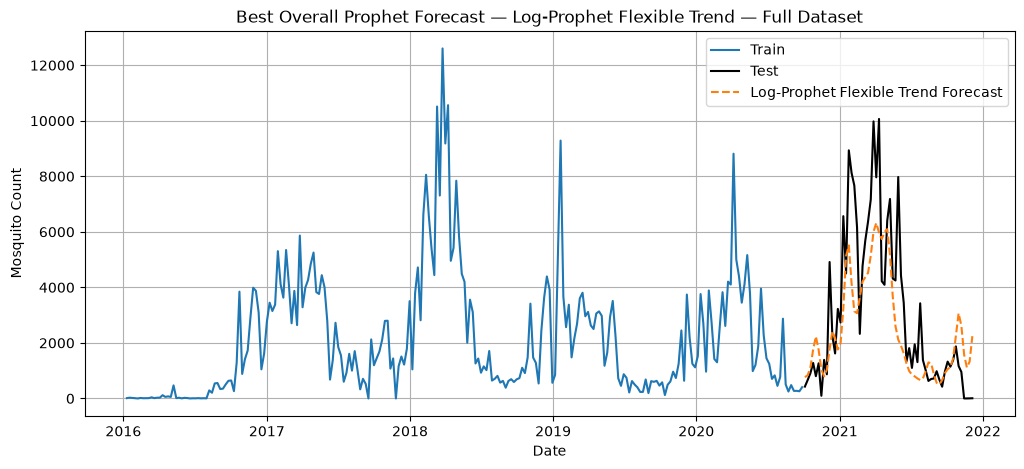

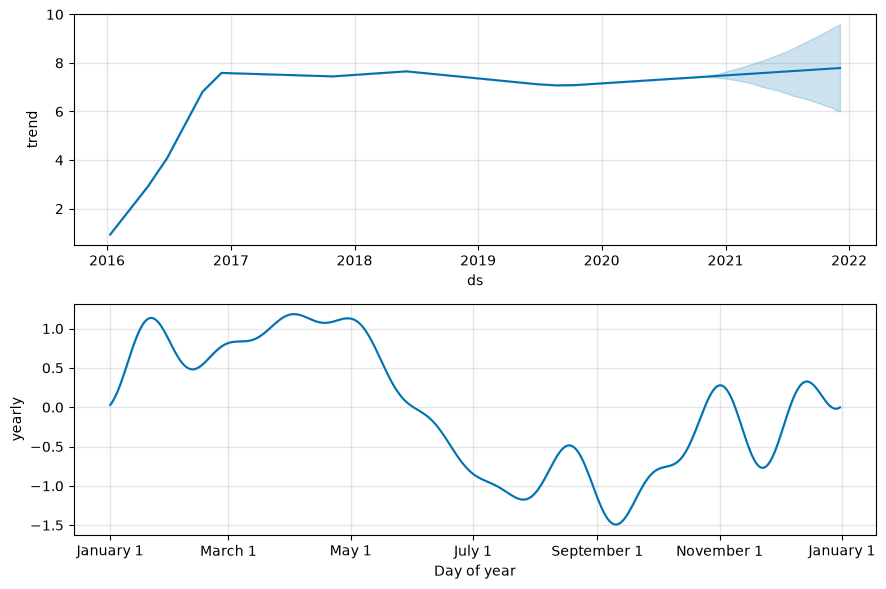

{'RMSE': np.float64(1875.5983574619472),
 'MAE': 1354.3709037387755,
 'R2': 0.5549814109668649,
 'nRMSE': np.float64(0.6078368859546436),
 'MAPE': np.float64(1324.1373424848255),
 'SMAPE': np.float64(56.57851478886009)}

In [60]:
if is_log_prophet:
    best_overall_prophet_test_forecast = np.expm1(
        best_overall_prophet_forecast.iloc[train_size:]["yhat"].values
    )
else:
    best_overall_prophet_test_forecast = (
        best_overall_prophet_forecast.iloc[train_size:]["yhat"].values
    )

best_overall_prophet_test_forecast = np.maximum(
    best_overall_prophet_test_forecast,
    0
)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    test_series.index,
    best_overall_prophet_test_forecast,
    label=f"{best_overall_prophet_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Overall Prophet Forecast — {best_overall_prophet_name} — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

best_overall_prophet_model.plot_components(best_overall_prophet_forecast)
plt.show()

add_result(
    best_overall_prophet_name,
    test_series.values,
    best_overall_prophet_test_forecast
)

## LSTM

In [61]:
tf.random.set_seed(42)
np.random.seed(42)

def create_lstm_sequences(data, lookback):
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [62]:
def fit_evaluate_lstm(train_series, test_series, lookback=12, units=64, dropout=0.2, epochs=150):
    scaler = MinMaxScaler()

    train_values = train_series.values.reshape(-1, 1)
    test_values = test_series.values.reshape(-1, 1)

    scaled_train = scaler.fit_transform(train_values)

    combined_values = np.concatenate([train_values[-lookback:], test_values])
    scaled_combined = scaler.transform(combined_values)

    X_train, y_train = create_lstm_sequences(scaled_train, lookback)
    X_test, y_test = create_lstm_sequences(scaled_combined, lookback)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    model = Sequential([
        LSTM(units, activation="tanh", input_shape=(lookback, 1)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    y_pred = scaler.inverse_transform(pred_scaled).flatten()
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    y_pred = np.maximum(y_pred, 0)

    metrics = compute_metrics(y_true, y_pred)

    return {
        "model": model,
        "history": history,
        "scaler": scaler,
        "lookback": lookback,
        "units": units,
        "dropout": dropout,
        "y_true": y_true,
        "y_pred": y_pred,
        "metrics": metrics
    }

In [63]:
lstm_configs = [
    {"name": "LSTM Lookback 4", "lookback": 4, "units": 32, "dropout": 0.2},
    {"name": "LSTM Lookback 8", "lookback": 8, "units": 32, "dropout": 0.2},
    {"name": "LSTM Lookback 12", "lookback": 12, "units": 64, "dropout": 0.2},
    {"name": "LSTM Lookback 16", "lookback": 16, "units": 64, "dropout": 0.2},
    {"name": "LSTM Lookback 24", "lookback": 24, "units": 64, "dropout": 0.3},
]

lstm_results = []
lstm_outputs = {}

for config in lstm_configs:
    print("Fitting:", config["name"])

    try:
        output = fit_evaluate_lstm(
            train_series=train_series,
            test_series=test_series,
            lookback=config["lookback"],
            units=config["units"],
            dropout=config["dropout"],
            epochs=150
        )

        metrics = output["metrics"]

        lstm_results.append({
            "Model": config["name"],
            "Lookback": config["lookback"],
            "Units": config["units"],
            "Dropout": config["dropout"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        lstm_outputs[config["name"]] = output

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

lstm_results_df = pd.DataFrame(lstm_results).sort_values("RMSE").reset_index(drop=True)
lstm_results_df

Fitting: LSTM Lookback 4
LSTM Lookback 4 {'RMSE': np.float64(1680.1326144421657), 'MAE': 1201.8171834638042, 'R2': 0.6429035032226174, 'nRMSE': np.float64(0.5444910805612493), 'MAPE': np.float64(281.8720775349), 'SMAPE': np.float64(51.46452133768476)}
Fitting: LSTM Lookback 8
LSTM Lookback 8 {'RMSE': np.float64(1730.9569774967151), 'MAE': 1210.5448219545426, 'R2': 0.6209722456327234, 'nRMSE': np.float64(0.5609620496505535), 'MAPE': np.float64(407.1632128517971), 'SMAPE': np.float64(50.71309184537917)}
Fitting: LSTM Lookback 12
LSTM Lookback 12 {'RMSE': np.float64(1795.445907144614), 'MAE': 1221.3450248472152, 'R2': 0.5922038553519049, 'nRMSE': np.float64(0.5818613802667152), 'MAPE': np.float64(794.3068963712303), 'SMAPE': np.float64(50.11887118396644)}
Fitting: LSTM Lookback 16
LSTM Lookback 16 {'RMSE': np.float64(1806.0785202570573), 'MAE': 1191.0038540747857, 'R2': 0.5873596243888992, 'nRMSE': np.float64(0.5853071576732243), 'MAPE': np.float64(674.1598412766491), 'SMAPE': np.float64(

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,1680.132614,1201.817183,0.642904,0.544491,281.872078,51.464521
1,LSTM Lookback 8,8,32,0.2,1730.956977,1210.544822,0.620972,0.560962,407.163213,50.713092
2,LSTM Lookback 24,24,64,0.3,1775.742803,1178.297684,0.601105,0.575476,800.464176,48.381761
3,LSTM Lookback 12,12,64,0.2,1795.445907,1221.345025,0.592204,0.581861,794.306896,50.118871
4,LSTM Lookback 16,16,64,0.2,1806.078520,1191.003854,0.587360,0.585307,674.159841,50.529833


Best LSTM model: LSTM Lookback 4


,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,1680.132614,1201.817183,0.642904,0.544491,281.872078,51.464521


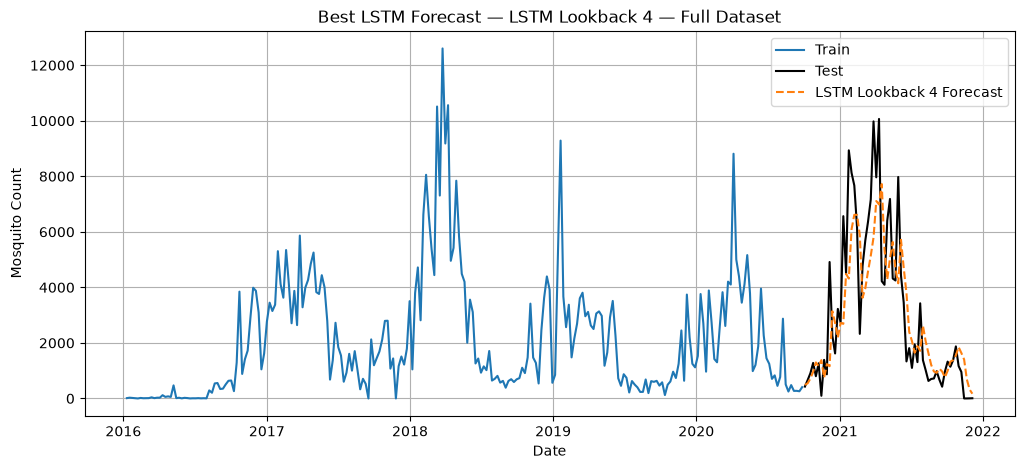

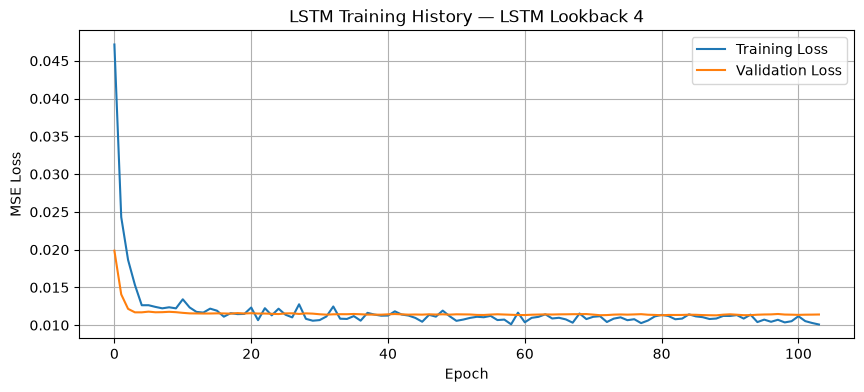

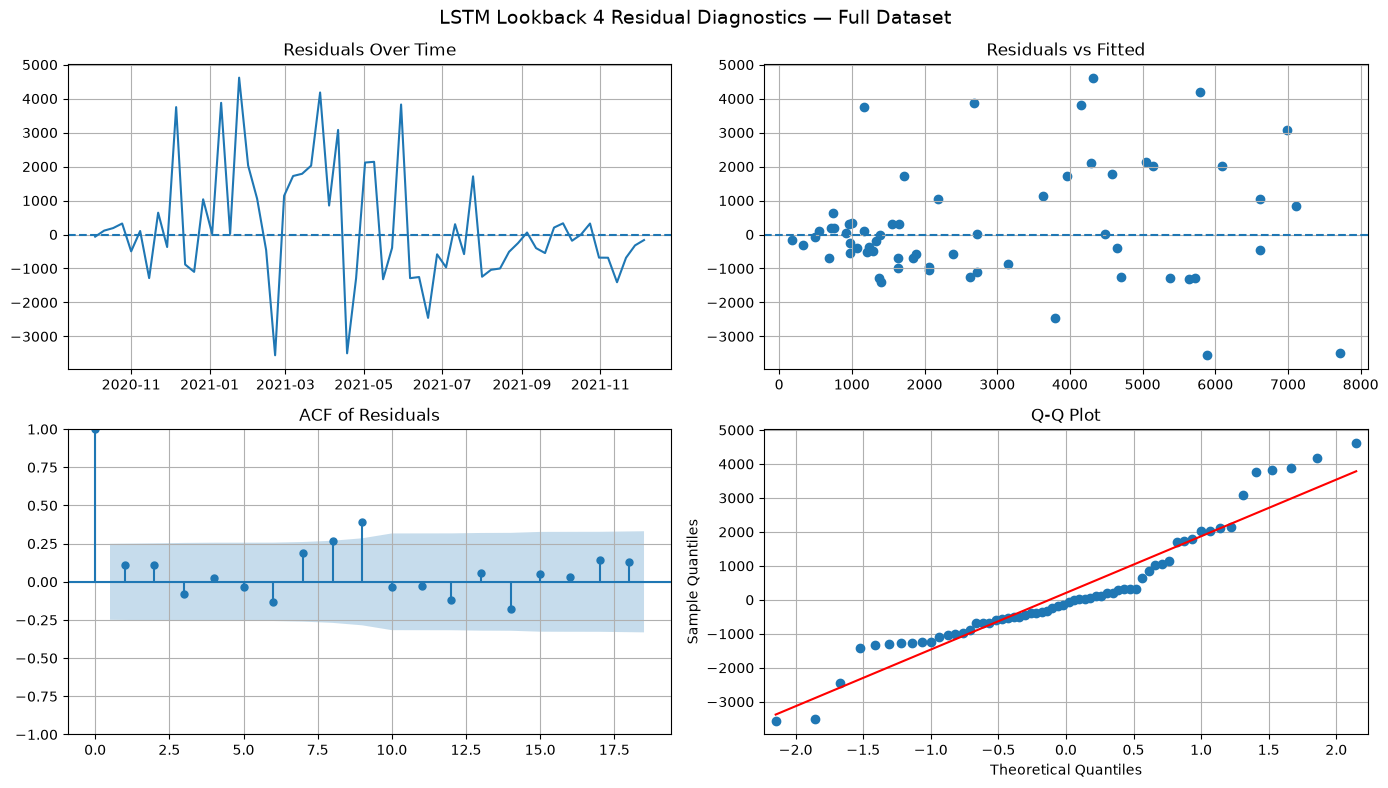

Ljung-Box Test:


,lb_stat,lb_pvalue
10,22.732526,0.011778
20,34.905407,0.020614


{'RMSE': np.float64(1680.1326144421657),
 'MAE': 1201.8171834638042,
 'R2': 0.6429035032226174,
 'nRMSE': np.float64(0.5444910805612493),
 'MAPE': np.float64(281.8720775349),
 'SMAPE': np.float64(51.46452133768476)}

In [64]:
best_lstm_name = lstm_results_df.iloc[0]["Model"]
best_lstm_output = lstm_outputs[best_lstm_name]

print("Best LSTM model:", best_lstm_name)
display(lstm_results_df.iloc[[0]])

lstm_test_index = test_series.index

best_lstm_true = pd.Series(
    best_lstm_output["y_true"],
    index=lstm_test_index,
    name="Observed"
)

best_lstm_pred = pd.Series(
    best_lstm_output["y_pred"],
    index=lstm_test_index,
    name="LSTM Forecast"
)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(best_lstm_true.index, best_lstm_true, label="Test", color="black")
plt.plot(
    best_lstm_pred.index,
    best_lstm_pred,
    label=f"{best_lstm_name} Forecast",
    linestyle="--"
)

plt.title(f"Best LSTM Forecast — {best_lstm_name} — Full Dataset")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

history = best_lstm_output["history"]

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title(f"LSTM Training History — {best_lstm_name}")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

lstm_residuals = best_lstm_true - best_lstm_pred

residual_diagnostics(
    lstm_residuals,
    fitted_values=best_lstm_pred,
    title=f"{best_lstm_name} Residual Diagnostics — Full Dataset"
)

add_result(
    best_lstm_name,
    best_lstm_true.values,
    best_lstm_pred.values
)

In [65]:
log_train_series = np.log1p(train_series)
log_test_series = np.log1p(test_series)

log_lstm_results = []
log_lstm_outputs = {}

for config in lstm_configs:
    model_name = "Log-" + config["name"]
    print("Fitting:", model_name)

    try:
        output = fit_evaluate_lstm(
            train_series=log_train_series,
            test_series=log_test_series,
            lookback=config["lookback"],
            units=config["units"],
            dropout=config["dropout"],
            epochs=150
        )

        y_true_original = np.expm1(output["y_true"])
        y_pred_original = np.expm1(output["y_pred"])
        y_pred_original = np.maximum(y_pred_original, 0)

        metrics = compute_metrics(y_true_original, y_pred_original)

        output["y_true_original"] = y_true_original
        output["y_pred_original"] = y_pred_original
        output["metrics_original"] = metrics

        log_lstm_results.append({
            "Model": model_name,
            "Lookback": config["lookback"],
            "Units": config["units"],
            "Dropout": config["dropout"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        log_lstm_outputs[model_name] = output

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", model_name, "|", e)

log_lstm_results_df = pd.DataFrame(log_lstm_results).sort_values("RMSE").reset_index(drop=True)
log_lstm_results_df

Fitting: Log-LSTM Lookback 4
Log-LSTM Lookback 4 {'RMSE': np.float64(2302.0681692007724), 'MAE': 1508.6649249292188, 'R2': 0.32959873560041475, 'nRMSE': np.float64(0.7460456241366134), 'MAPE': np.float64(122.24304094477067), 'SMAPE': np.float64(59.02689500316157)}
Fitting: Log-LSTM Lookback 8
Log-LSTM Lookback 8 {'RMSE': np.float64(1985.252300067169), 'MAE': 1328.1803162482477, 'R2': 0.5014257086150866, 'nRMSE': np.float64(0.6433731246918113), 'MAPE': np.float64(89.75588600806739), 'SMAPE': np.float64(55.07983942886073)}
Fitting: Log-LSTM Lookback 12
Log-LSTM Lookback 12 {'RMSE': np.float64(1916.03514226649), 'MAE': 1279.8180268503004, 'R2': 0.5355858907081711, 'nRMSE': np.float64(0.620941487617268), 'MAPE': np.float64(78.4795767344407), 'SMAPE': np.float64(52.82593745020516)}
Fitting: Log-LSTM Lookback 16
Log-LSTM Lookback 16 {'RMSE': np.float64(2175.7227555285267), 'MAE': 1415.4913163031301, 'R2': 0.4011672098099567, 'nRMSE': np.float64(0.70510007601558), 'MAPE': np.float64(82.723774

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Log-LSTM Lookback 12,12,64,0.2,1916.035142,1279.818027,0.535586,0.620941,78.479577,52.825937
1,Log-LSTM Lookback 8,8,32,0.2,1985.252300,1328.180316,0.501426,0.643373,89.755886,55.079839
2,Log-LSTM Lookback 16,16,64,0.2,2175.722756,1415.491316,0.401167,0.705100,82.723775,57.573788
3,Log-LSTM Lookback 4,4,32,0.2,2302.068169,1508.664925,0.329599,0.746046,122.243041,59.026895
4,Log-LSTM Lookback 24,24,64,0.3,2387.067160,1548.086203,0.279178,0.773592,151.366852,59.786444


In [66]:
all_lstm_results_df = pd.concat(
    [lstm_results_df, log_lstm_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

display(all_lstm_results_df)

best_overall_lstm_name = all_lstm_results_df.iloc[0]["Model"]

if best_overall_lstm_name.startswith("Log-"):
    best_overall_lstm_output = log_lstm_outputs[best_overall_lstm_name]
    best_overall_lstm_true = pd.Series(
        best_overall_lstm_output["y_true_original"],
        index=test_series.index
    )
    best_overall_lstm_pred = pd.Series(
        best_overall_lstm_output["y_pred_original"],
        index=test_series.index
    )
else:
    best_overall_lstm_output = lstm_outputs[best_overall_lstm_name]
    best_overall_lstm_true = pd.Series(
        best_overall_lstm_output["y_true"],
        index=test_series.index
    )
    best_overall_lstm_pred = pd.Series(
        best_overall_lstm_output["y_pred"],
        index=test_series.index
    )

print("Best overall LSTM model:", best_overall_lstm_name)
display(all_lstm_results_df.iloc[[0]])

add_result(
    best_overall_lstm_name,
    best_overall_lstm_true.values,
    best_overall_lstm_pred.values
)

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,1680.132614,1201.817183,0.642904,0.544491,281.872078,51.464521
1,LSTM Lookback 8,8,32,0.2,1730.956977,1210.544822,0.620972,0.560962,407.163213,50.713092
2,LSTM Lookback 24,24,64,0.3,1775.742803,1178.297684,0.601105,0.575476,800.464176,48.381761
3,LSTM Lookback 12,12,64,0.2,1795.445907,1221.345025,0.592204,0.581861,794.306896,50.118871
4,LSTM Lookback 16,16,64,0.2,1806.078520,1191.003854,0.587360,0.585307,674.159841,50.529833
5,Log-LSTM Lookback 12,12,64,0.2,1916.035142,1279.818027,0.535586,0.620941,78.479577,52.825937
6,Log-LSTM Lookback 8,8,32,0.2,1985.252300,1328.180316,0.501426,0.643373,89.755886,55.079839
7,Log-LSTM Lookback 16,16,64,0.2,2175.722756,1415.491316,0.401167,0.705100,82.723775,57.573788
8,Log-LSTM Lookback 4,4,32,0.2,2302.068169,1508.664925,0.329599,0.746046,122.243041,59.026895
9,Log-LSTM Lookback 24,24,64,0.3,2387.067160,1548.086203,0.279178,0.773592,151.366852,59.786444


Best overall LSTM model: LSTM Lookback 4


,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,1680.132614,1201.817183,0.642904,0.544491,281.872078,51.464521


{'RMSE': np.float64(1680.1326144421657),
 'MAE': 1201.8171834638042,
 'R2': 0.6429035032226174,
 'nRMSE': np.float64(0.5444910805612493),
 'MAPE': np.float64(281.8720775349),
 'SMAPE': np.float64(51.46452133768476)}

In [67]:
final_results_df = pd.DataFrame(model_results)

final_results_df = final_results_df.drop_duplicates(
    subset=["Series", "Model"],
    keep="last"
)

final_results_df = final_results_df.sort_values("RMSE").reset_index(drop=True)

display(final_results_df)

final_results_df.to_csv("full_dataset_univariate_final_model_summary.csv", index=False)

,Series,Model,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Full Dataset,Rolling Mean,1601.172730,1098.593385,0.543104,0.602584,146.546204,48.778136
1,Full Dataset,"Rolling ARIMA(4, 1, 4)",1618.643168,1132.249105,0.533079,0.609159,169.702373,54.727682
2,Full Dataset,Naive,1628.019829,1110.081712,0.527653,0.612687,60.269076,49.027253
3,Full Dataset,LSTM Lookback 4,1680.132614,1201.817183,0.642904,0.544491,281.872078,51.464521
4,Full Dataset,Log-Prophet Flexible Trend,1875.598357,1354.370904,0.554981,0.607837,1324.137342,56.578515
5,Full Dataset,"Rolling Log-ARIMA(4, 1, 4)",1913.567802,1268.141663,0.347427,0.720150,63.993569,54.367547
6,Full Dataset,ETS Add Trend + Add Season,2068.416549,1411.019996,0.458779,0.670325,1942.493336,54.901599
7,Full Dataset,"Log-SARIMA(3, 0, 4)(1, 1, 0, 52)",2380.580771,1629.138171,0.283091,0.771490,1622.932213,67.715898
8,Full Dataset,"SARIMA(3, 0, 2)(1, 1, 0, 52)",2440.321915,1734.740522,0.246657,0.790850,1421.298491,79.931037
9,Full Dataset,Seasonal Naive,2567.236682,1801.564202,-0.174555,0.966151,475.624828,82.800151


In [68]:
final_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}"
})

,Series,Model,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Full Dataset,Rolling Mean,1601.17,1098.59,0.543,0.603,146.55,48.78
1,Full Dataset,"Rolling ARIMA(4, 1, 4)",1618.64,1132.25,0.533,0.609,169.70,54.73
2,Full Dataset,Naive,1628.02,1110.08,0.528,0.613,60.27,49.03
3,Full Dataset,LSTM Lookback 4,1680.13,1201.82,0.643,0.544,281.87,51.46
4,Full Dataset,Log-Prophet Flexible Trend,1875.60,1354.37,0.555,0.608,1324.14,56.58
5,Full Dataset,"Rolling Log-ARIMA(4, 1, 4)",1913.57,1268.14,0.347,0.720,63.99,54.37
6,Full Dataset,ETS Add Trend + Add Season,2068.42,1411.02,0.459,0.670,1942.49,54.90
7,Full Dataset,"Log-SARIMA(3, 0, 4)(1, 1, 0, 52)",2380.58,1629.14,0.283,0.771,1622.93,67.72
8,Full Dataset,"SARIMA(3, 0, 2)(1, 1, 0, 52)",2440.32,1734.74,0.247,0.791,1421.30,79.93
9,Full Dataset,Seasonal Naive,2567.24,1801.56,-0.175,0.966,475.62,82.80


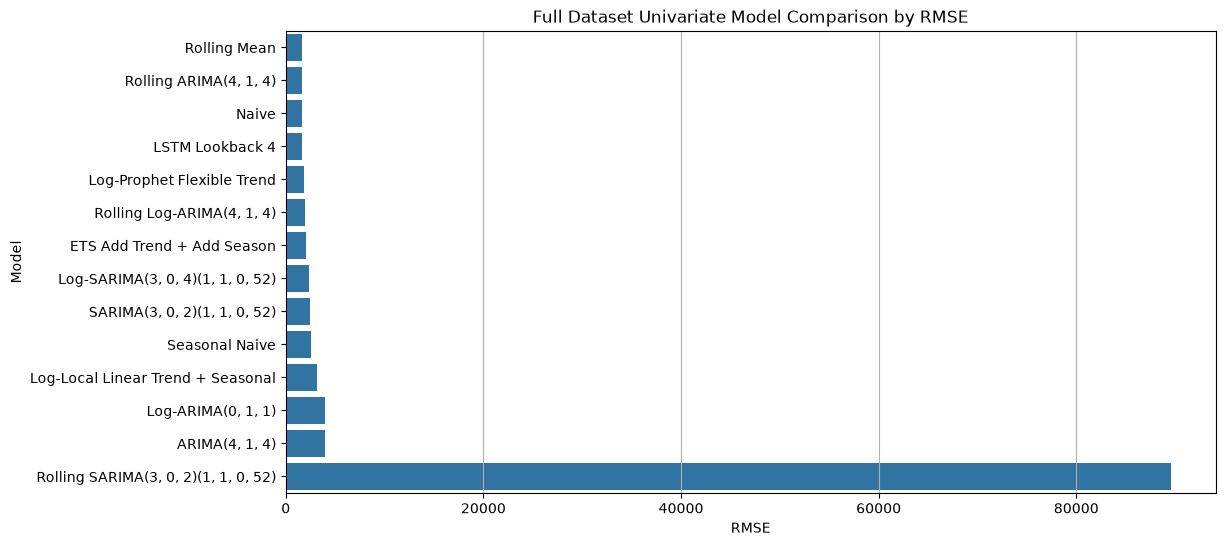

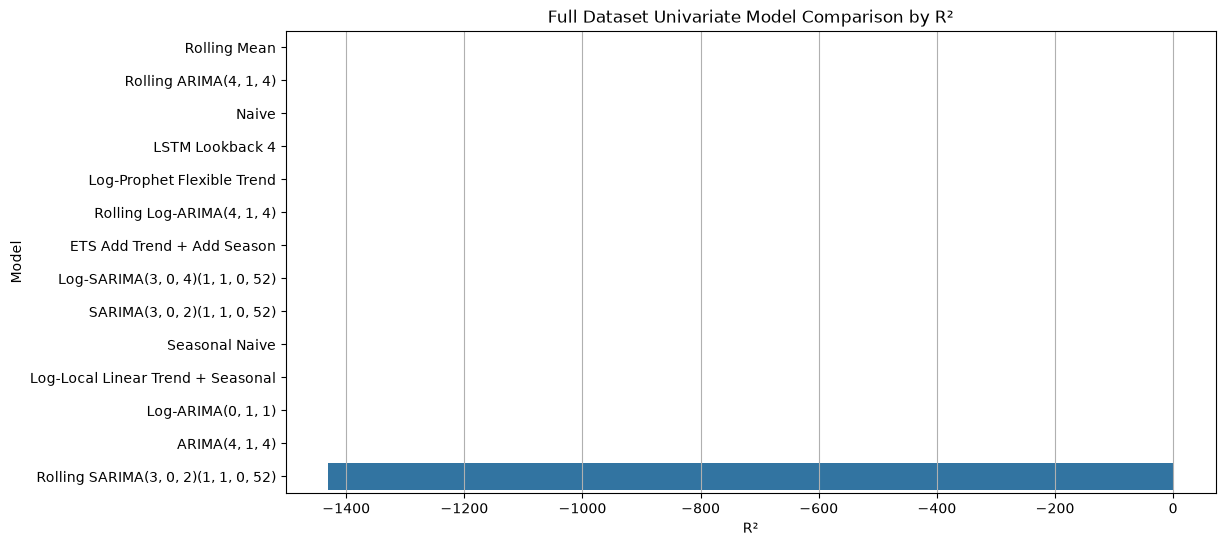

In [69]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results_df,
    x="RMSE",
    y="Model"
)

plt.title("Full Dataset Univariate Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results_df,
    x="R2",
    y="Model"
)

plt.title("Full Dataset Univariate Model Comparison by R²")
plt.xlabel("R²")
plt.ylabel("Model")
plt.show()

In [70]:
# Peak / Outbreak Performance Analysis

def compute_peak_metrics(y_true, y_pred, percentile=90):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    threshold = np.percentile(y_true, percentile)
    peak_mask = y_true >= threshold

    if peak_mask.sum() == 0:
        return {
            "Peak_Threshold": threshold,
            "Peak_RMSE": np.nan,
            "Peak_MAE": np.nan,
            "Peak_Count": 0
        }

    return {
        "Peak_Threshold": threshold,
        "Peak_RMSE": np.sqrt(mean_squared_error(y_true[peak_mask], y_pred[peak_mask])),
        "Peak_MAE": mean_absolute_error(y_true[peak_mask], y_pred[peak_mask]),
        "Peak_Count": peak_mask.sum()
    }


peak_results = []

peak_results.append({
    "Model": f"Rolling ARIMA{best_arima_order}",
    **compute_peak_metrics(y_true_roll_arima, y_pred_roll_arima)
})

peak_results.append({
    "Model": best_overall_ets_name,
    **compute_peak_metrics(test_series.values, best_overall_ets_forecast.values)
})

peak_results.append({
    "Model": best_overall_prophet_name,
    **compute_peak_metrics(test_series.values, best_overall_prophet_test_forecast)
})

peak_results.append({
    "Model": best_overall_lstm_name,
    **compute_peak_metrics(best_overall_lstm_true.values, best_overall_lstm_pred.values)
})

peak_results_df = pd.DataFrame(peak_results).sort_values("Peak_RMSE").reset_index(drop=True)

display(peak_results_df)

,Model,Peak_Threshold,Peak_RMSE,Peak_MAE,Peak_Count
0,"Rolling ARIMA(4, 1, 4)",5748.4,3111.206858,2581.481621,26
1,LSTM Lookback 4,7619.6,3137.476851,2806.337960,7
2,Log-Prophet Flexible Trend,7619.6,4095.893429,3925.394100,7
3,ETS Add Trend + Add Season,7619.6,4763.272792,4558.900070,7


In [71]:
peak_results_df.style.format({
    "Peak_Threshold": "{:.2f}",
    "Peak_RMSE": "{:.2f}",
    "Peak_MAE": "{:.2f}",
    "Peak_Count": "{:.0f}"
})

,Model,Peak_Threshold,Peak_RMSE,Peak_MAE,Peak_Count
0,"Rolling ARIMA(4, 1, 4)",5748.40,3111.21,2581.48,26
1,LSTM Lookback 4,7619.60,3137.48,2806.34,7
2,Log-Prophet Flexible Trend,7619.60,4095.89,3925.39,7
3,ETS Add Trend + Add Season,7619.60,4763.27,4558.90,7
